# Analyzes mean and avg of the GENERATED connectomes 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

def quality_check_regarding_means_and_avgs(path_to_csv_file, bin_into_100=True):
    path_to_csv_file = Path(path_to_csv_file)
    df = pd.read_csv(path_to_csv_file)

    # Define the columns to analyze (excluding eta, gamma, and other metadata)
    metric_columns = [
        'MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)',
        'avg_communicability',
        'global_efficiency',
        'modularity',
        'avg_clustering',
        'transitivity',
        'avg_edge_distance',
        'wiring_cost',
        'char_path_length',
        'richclub_n_edges',
        'richclub_avg_length'
    ]

    # Group by eta and gamma, then calculate mean and std for each metric. Group into 100 bins for eta and gamma first!
    if bin_into_100: 
        df['eta'] = pd.cut(df['eta'], bins=100, labels=False)
        df['gamma'] = pd.cut(df['gamma'], bins=100, labels=False)
    # Group by eta and gamma, then calculate mean and std for each metric
    grouped = df.groupby(['eta', 'gamma'])[metric_columns].agg(['mean', 'std']).reset_index()

    # Display the grouped statistics
    print("Grouped Statistics by Eta and Gamma:")
    print(grouped)
    print(f"\nNumber of unique eta-gamma combinations: {len(grouped)}")

    # Prepare data for heatmaps
    output_folder = path_to_csv_file.parent / 'heatmaps_mean_and_std/'
    os.makedirs(output_folder, exist_ok=True)

    # plot it
    things = ["mean", "std", "std_dev_normalized_by_mean"]
    for metric in metric_columns:
        for thing in things:
            plt.figure(figsize=(10, 8))
            pivot_table = grouped.pivot(index='eta', columns='gamma', values=(metric, thing if thing != "std_dev_normalized_by_mean" else 'std'))
            if thing == "std_dev_normalized_by_mean":
                pivot_table = pivot_table / grouped.pivot(index='eta', columns='gamma', values=(metric, 'mean'))
            sns.heatmap(pivot_table, # annot=True, 
                        fmt=".2f", cmap="Blues") # YlGnBu")
            
            # Invert y-axis
            plt.gca().invert_yaxis()

            plt.title(f'[{metric.replace("_", " ").title()}] - {thing.replace("_", " ").title()}') #  by Eta and Gamma')
            plt.xlabel('Gamma (rounded)')
            plt.ylabel('Eta (rounded)')
            
            # Make ticks readable
            distance = 10
            plt.xticks(ticks=np.arange(len(pivot_table.columns)//distance)*distance, labels=[f"{x:.1f}" for x in pivot_table.columns[::distance]])  # Show not every label
            plt.yticks(ticks=np.arange(len(pivot_table.index)//distance)*distance, labels=[f"{y:.1f}" for y in pivot_table.index[::distance]])  # Show not every label

            plt.savefig(output_folder / f'{metric}_{thing}.pdf')
            plt.show()
        
        
    # Similar to the style above: Plot how many samples went into each point in the heatmap
    plt.figure(figsize=(10, 8))
    count_pivot_table = df.groupby(['eta', 'gamma']).size().unstack(fill_value=0)
    sns.heatmap(count_pivot_table, # annot=True, 
                fmt="d", cmap="Greens")
    plt.title('Number of Samples by Eta and Gamma')
    plt.xlabel('Gamma (rounded)')
    plt.ylabel('Eta (rounded)')   
    
    # Change ticks to not have the bin numbers but the actual ranges
    plt.xticks(ticks=np.arange(len(pivot_table.columns)), labels=[f"{x:.1f}" for x in pivot_table.columns])
    plt.yticks(ticks=np.arange(len(pivot_table.index)), labels=[f"{y:.1f}" for y in pivot_table.index])
    
    # Make ticks readable
    distance = 10
    plt.xticks(ticks=np.arange(len(count_pivot_table.columns)//distance)*distance, labels=[f"{x:.1f}" for x in count_pivot_table.columns[::distance]])  # Show not every label
    plt.yticks(ticks=np.arange(len(count_pivot_table.index)//distance)*distance, labels=[f"{y:.1f}" for y in count_pivot_table.index[::distance]])  # Show not every label
    plt.savefig(output_folder / f'count_samples.pdf')
    plt.show()


Grouped Statistics by Eta and Gamma:
      eta     gamma  \
                      
0    -8.0 -0.100000   
1    -8.0 -0.088889   
2    -8.0 -0.077778   
3    -8.0 -0.066667   
4    -8.0 -0.055556   
...   ...       ...   
9995  3.0  0.955556   
9996  3.0  0.966667   
9997  3.0  0.977778   
9998  3.0  0.988889   
9999  3.0  1.000000   

     MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)  \
                                                                 mean   
0                                                 0.835                 
1                                                 0.825                 
2                                                 0.850                 
3                                                 0.845                 
4                                                 0.790                 
...                                                 ...                 
9995                                              0.950                 
9996  

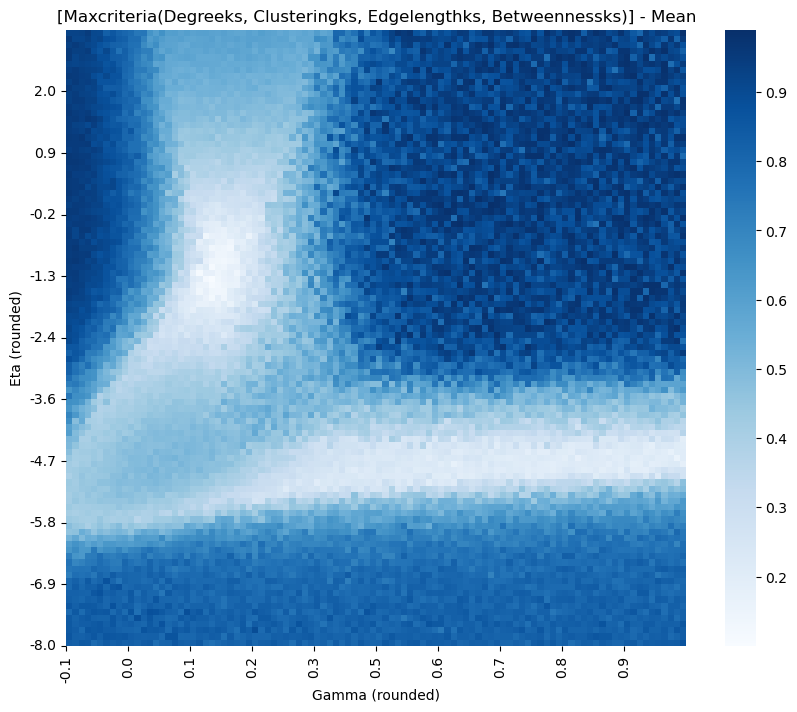

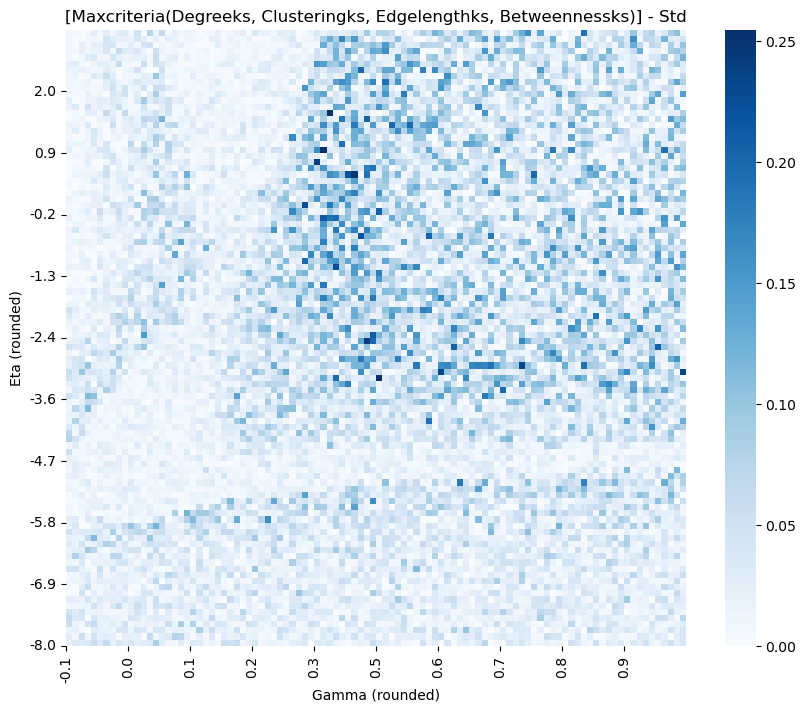

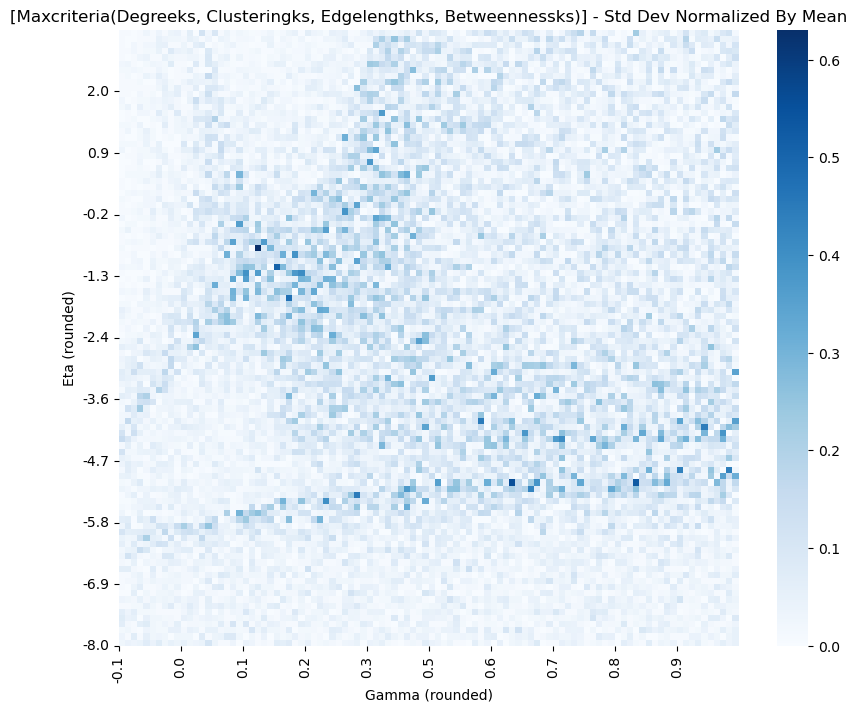

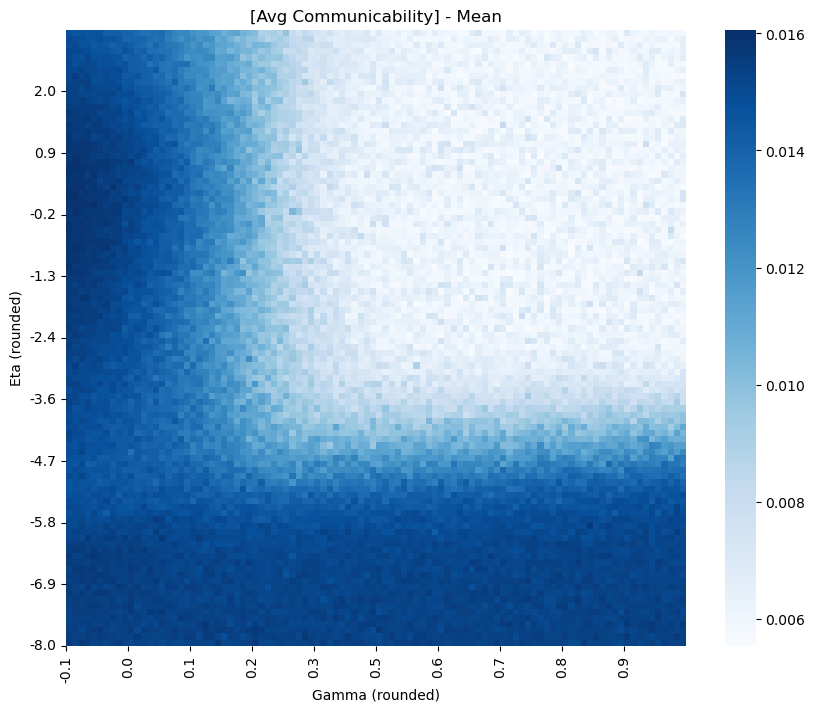

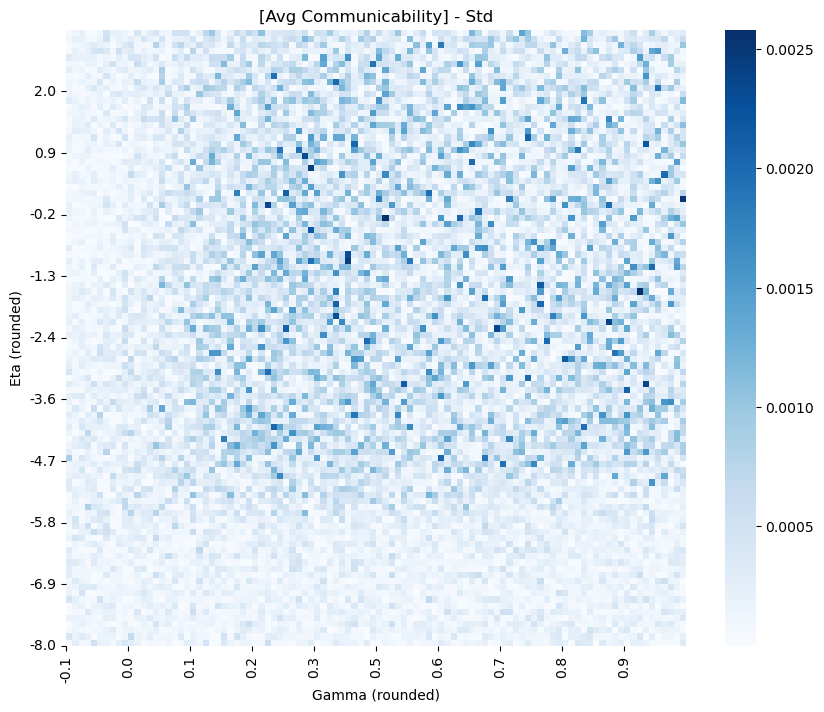

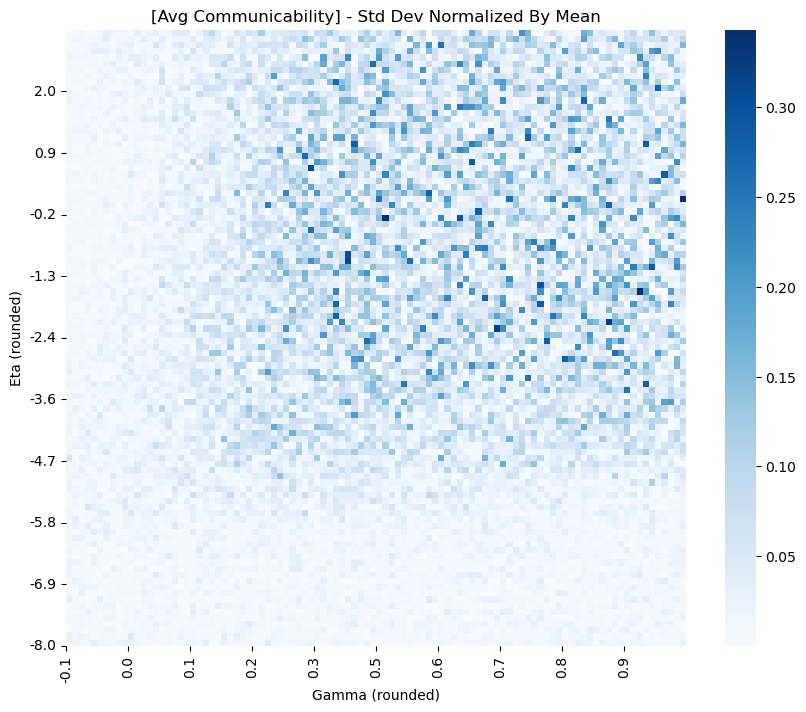

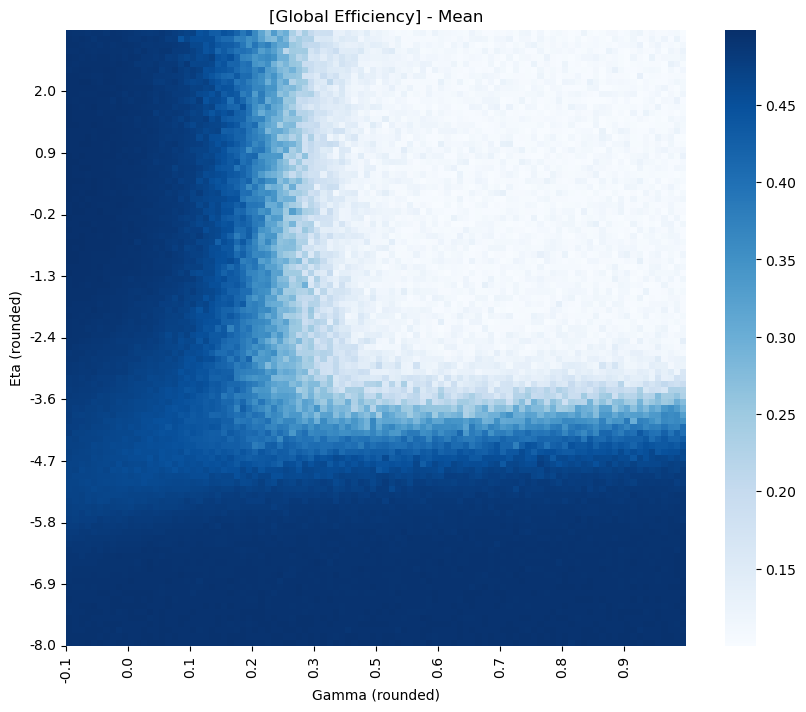

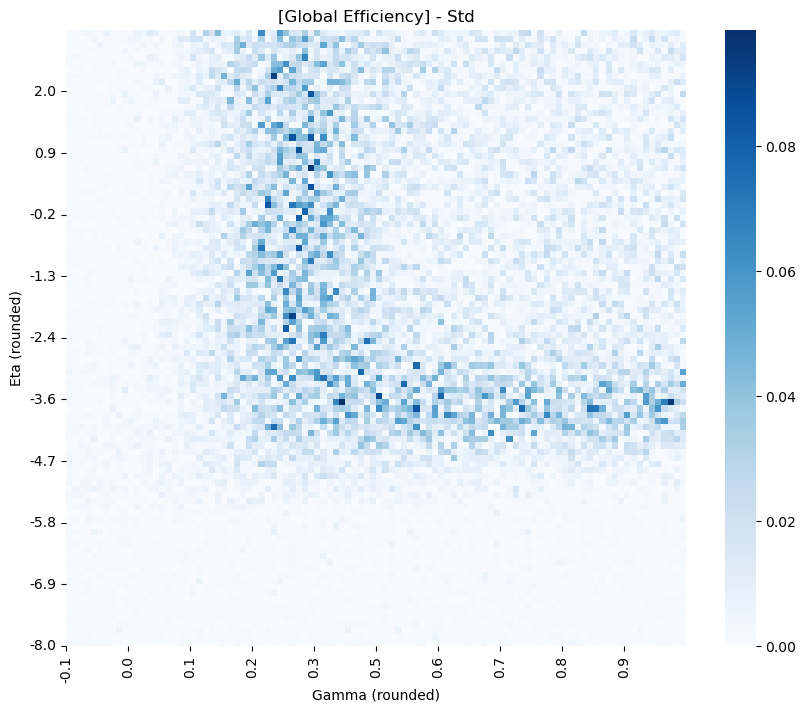

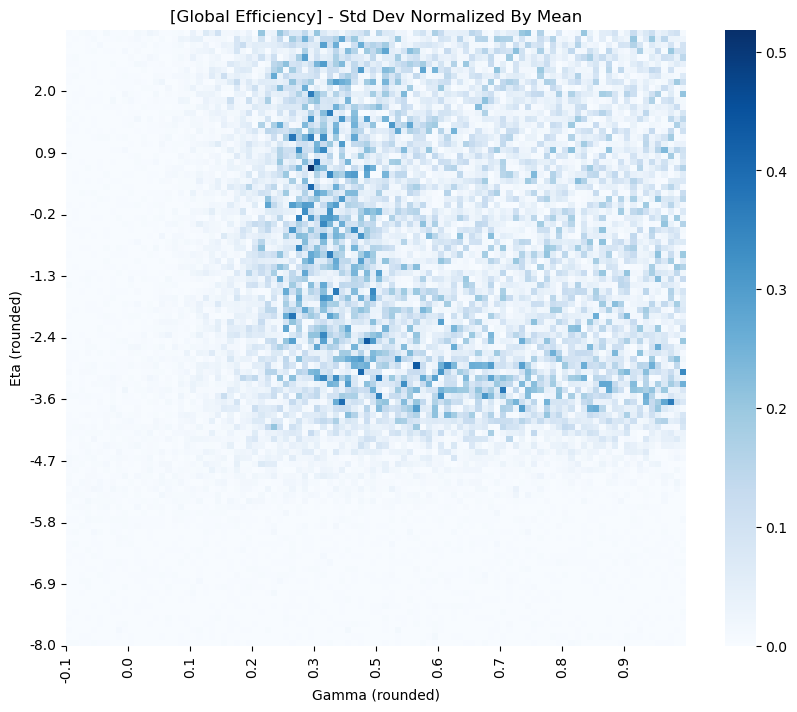

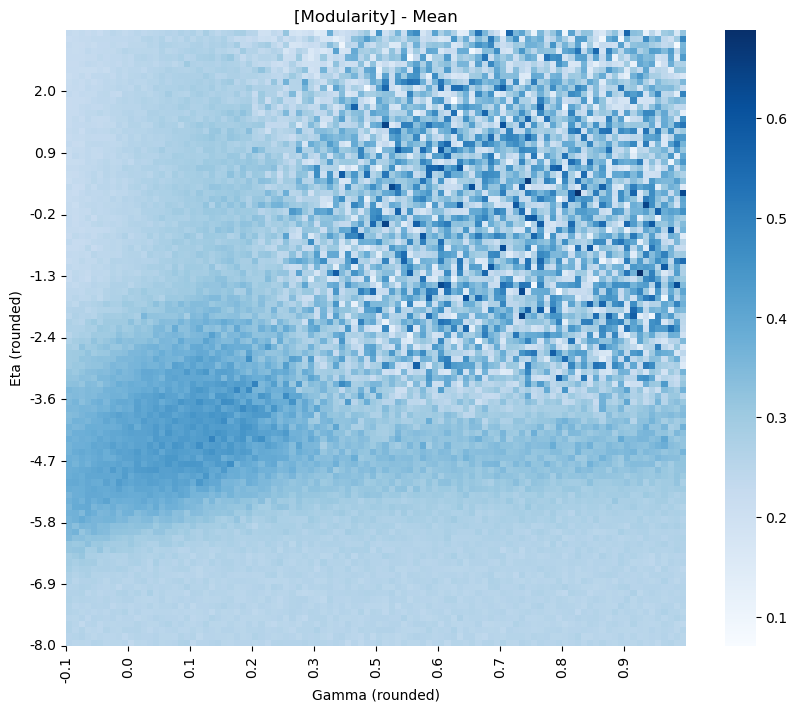

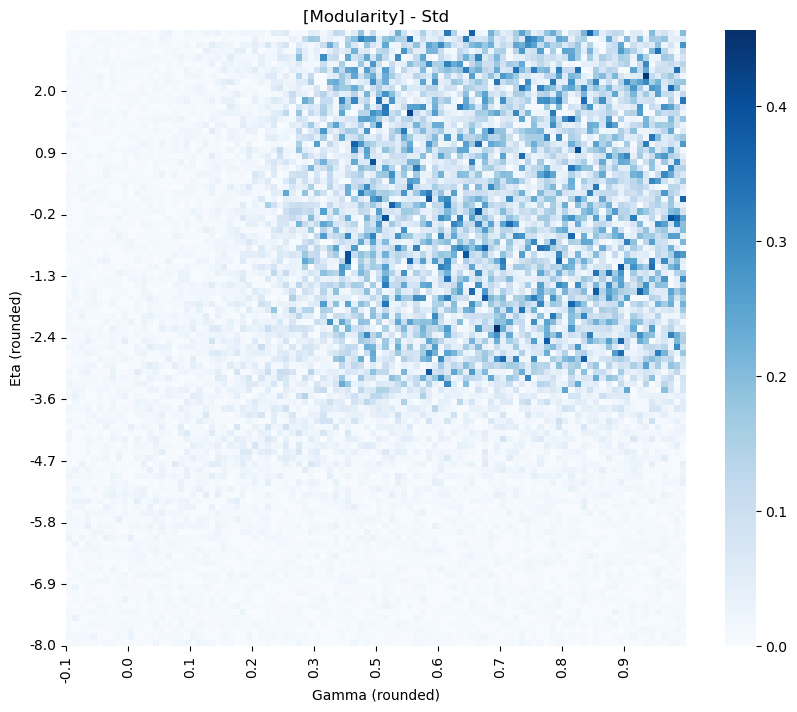

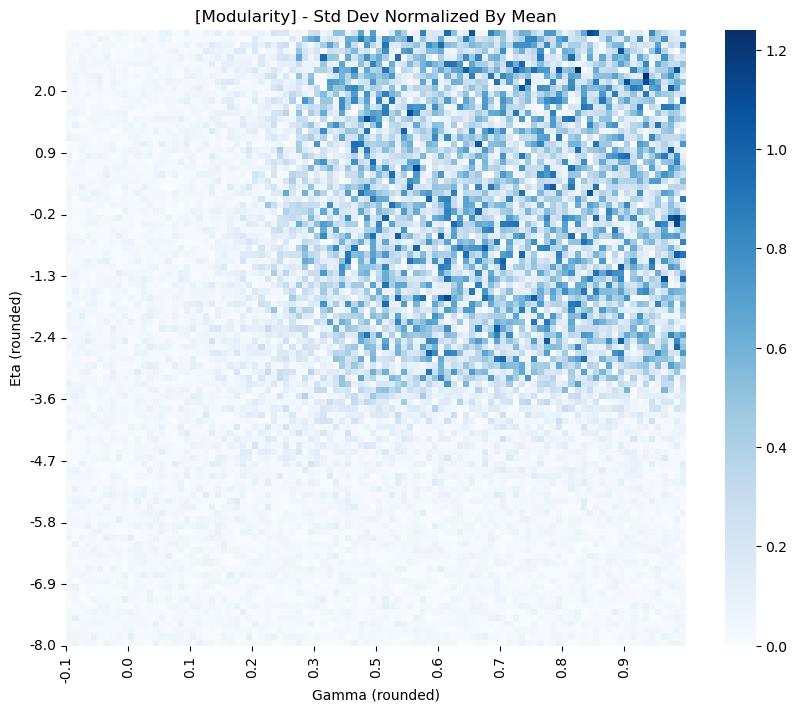

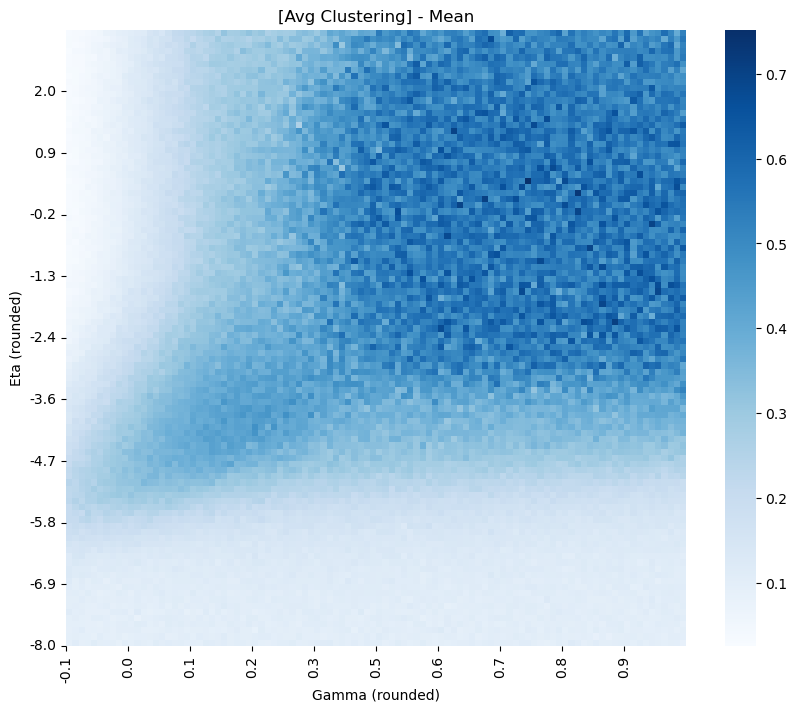

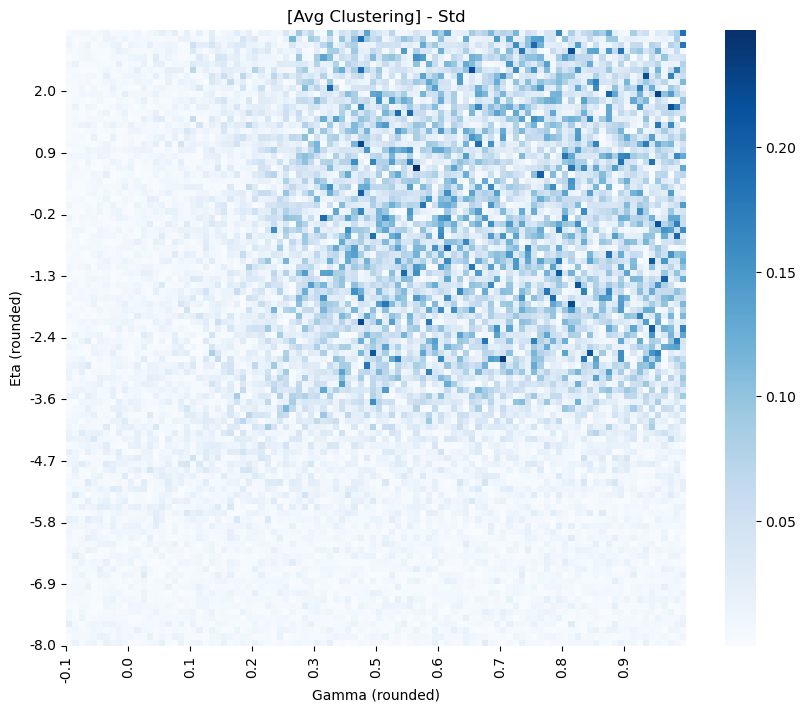

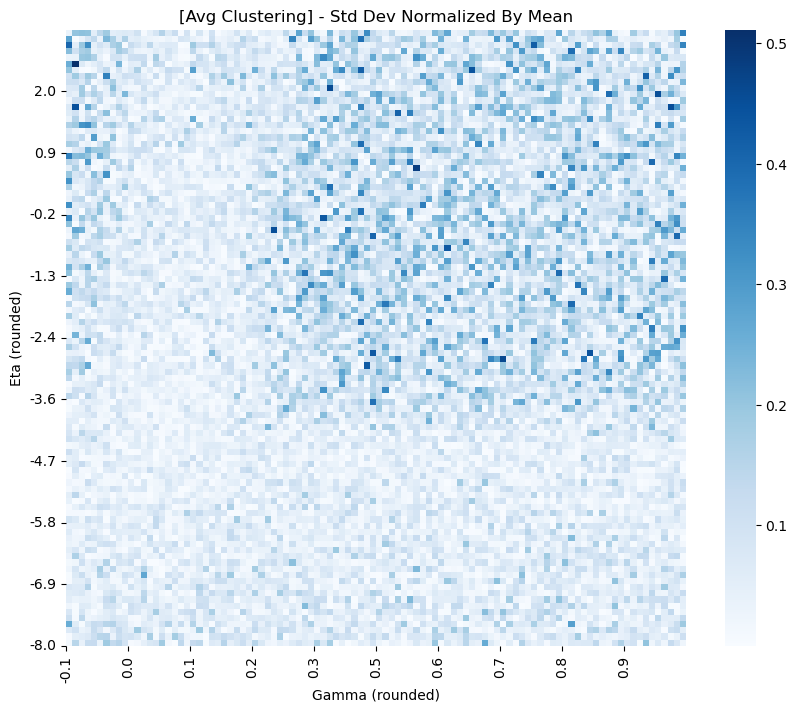

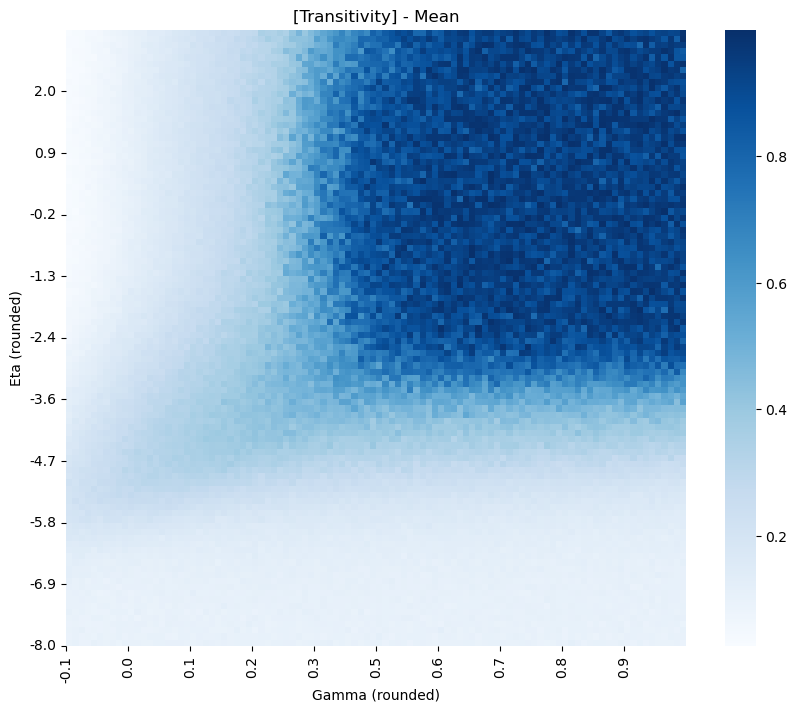

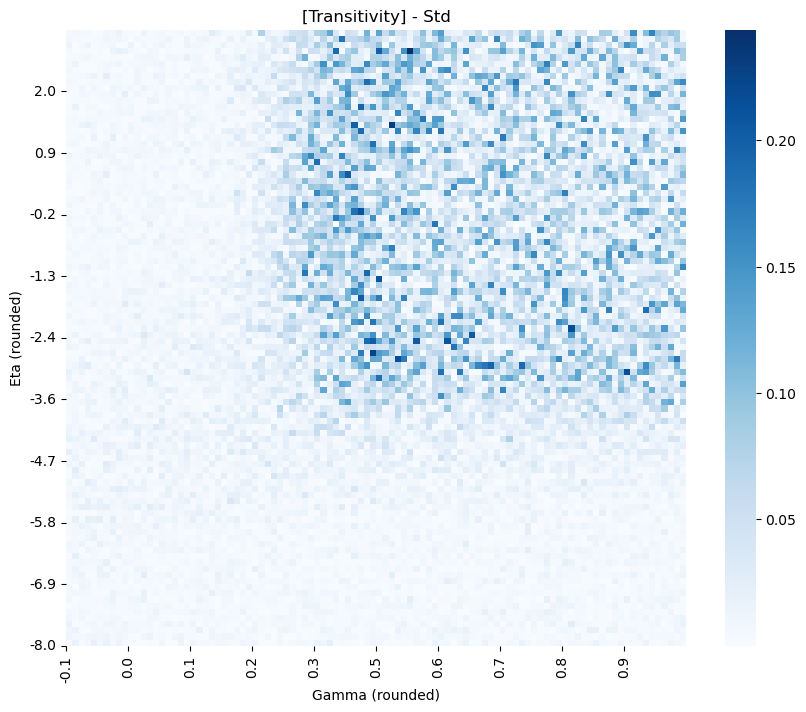

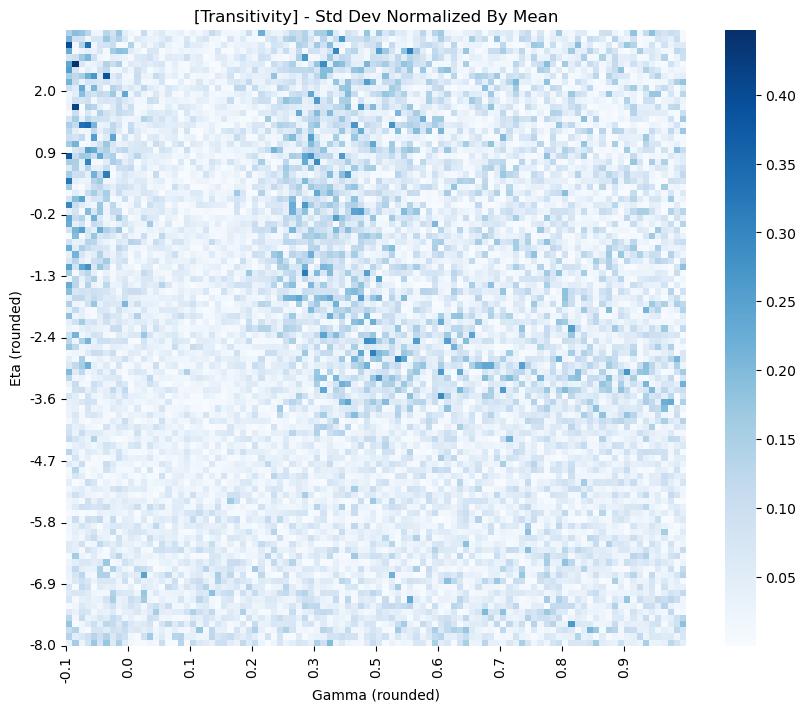

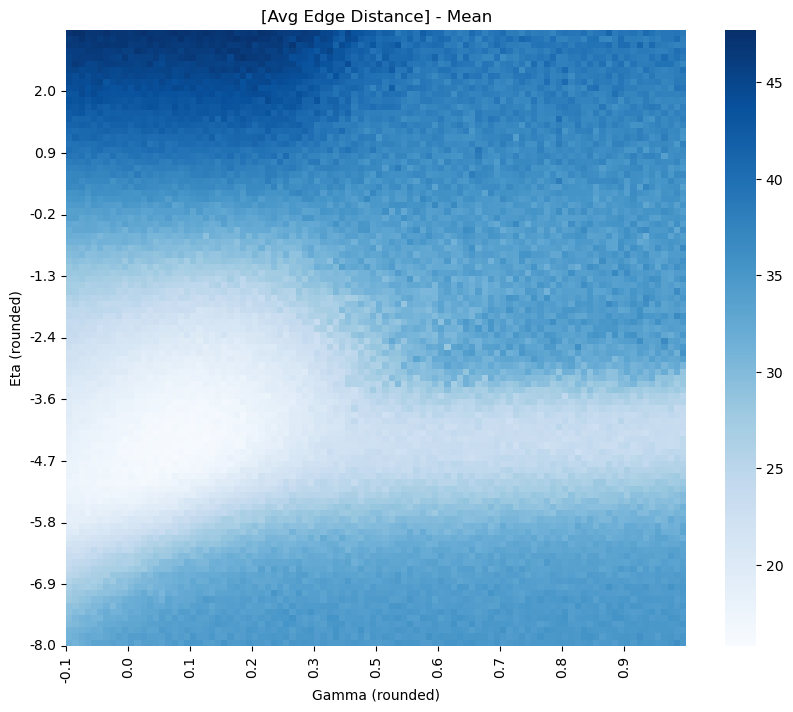

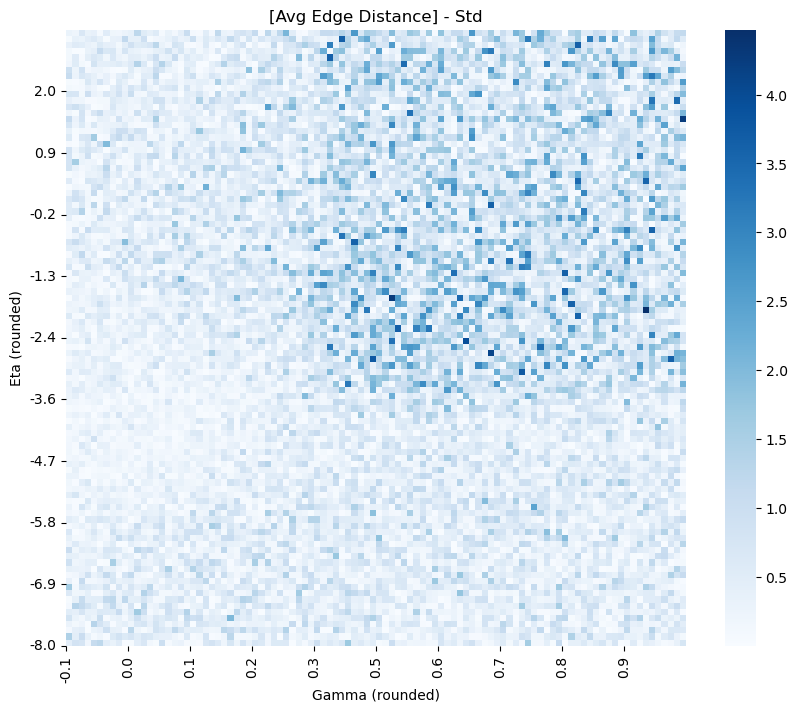

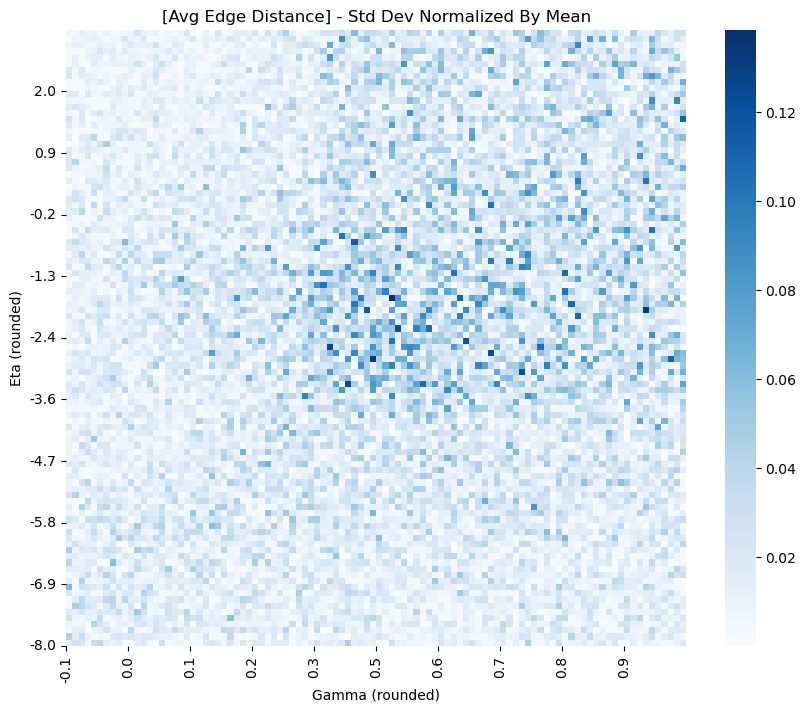

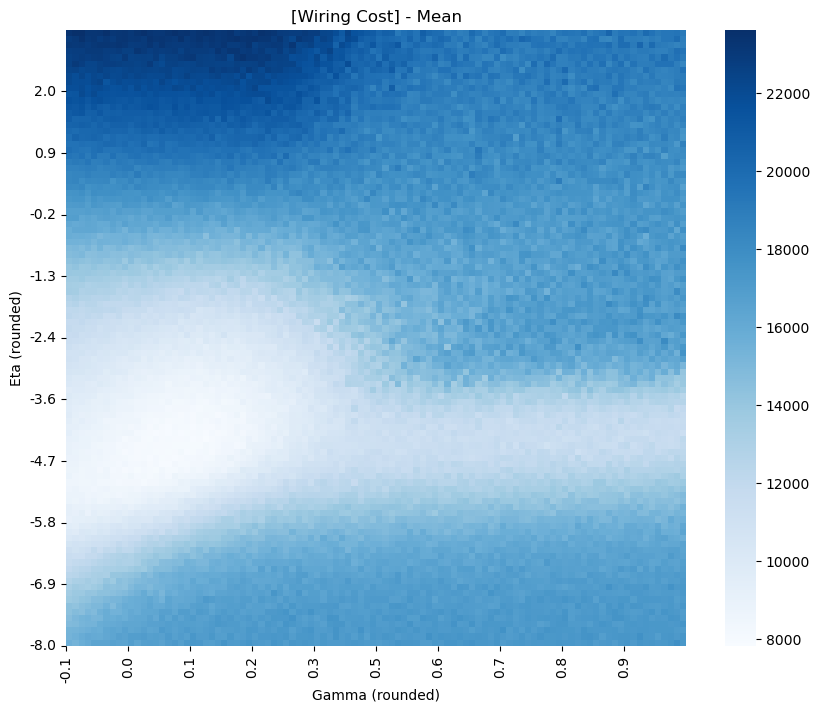

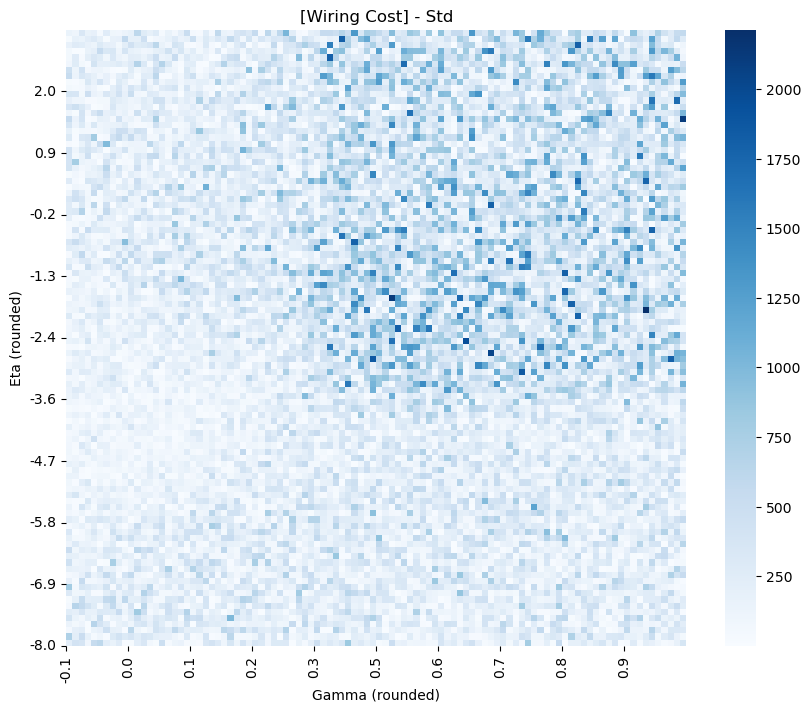

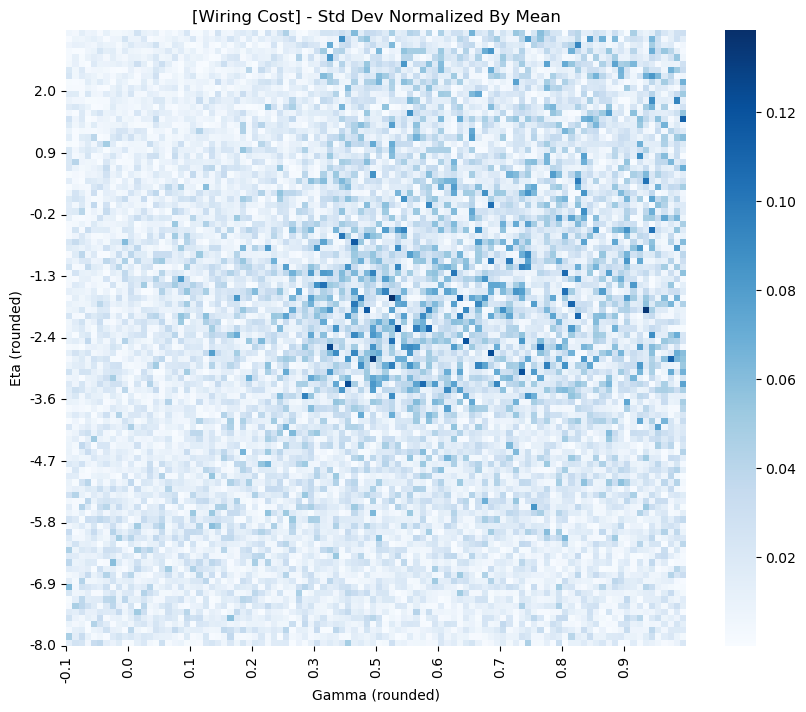

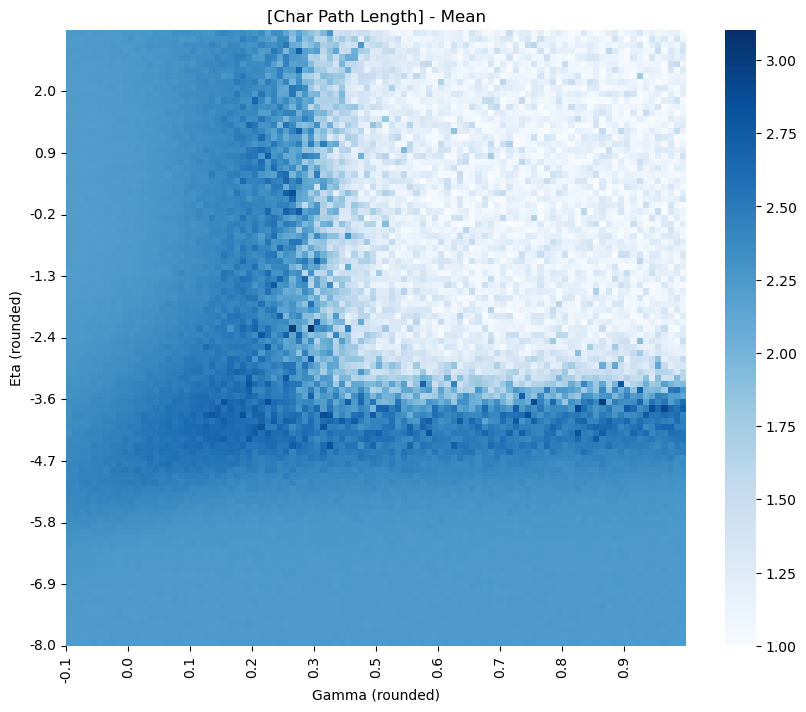

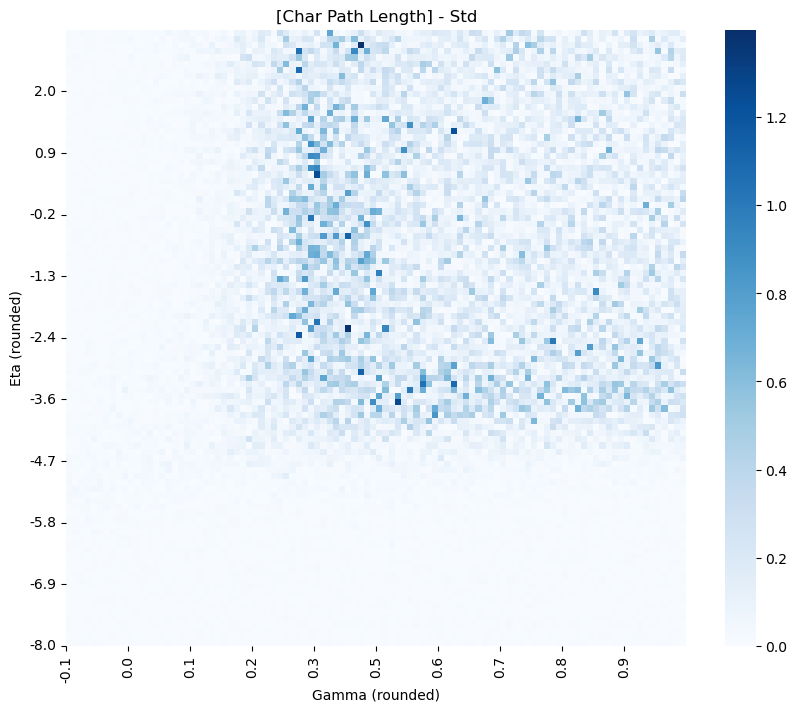

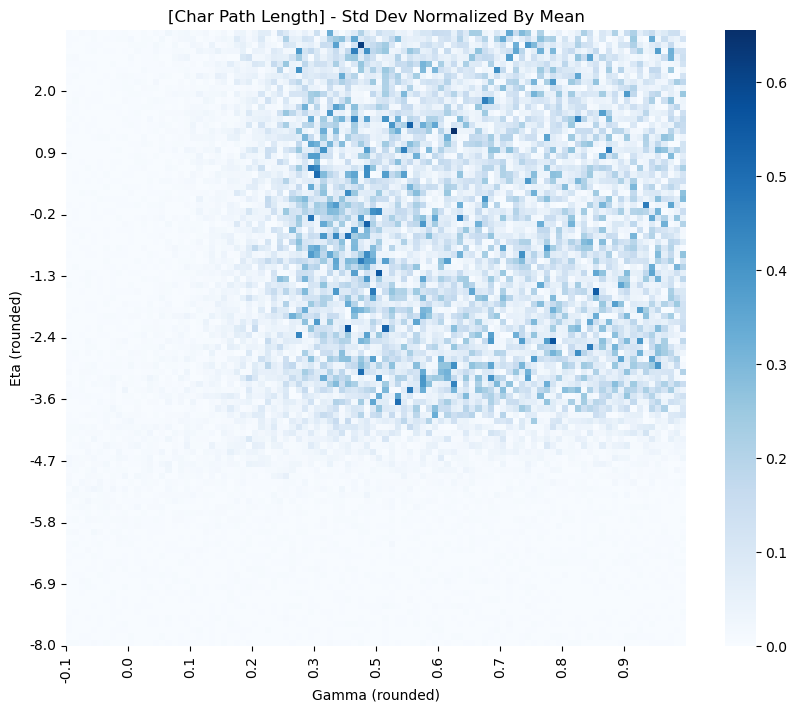

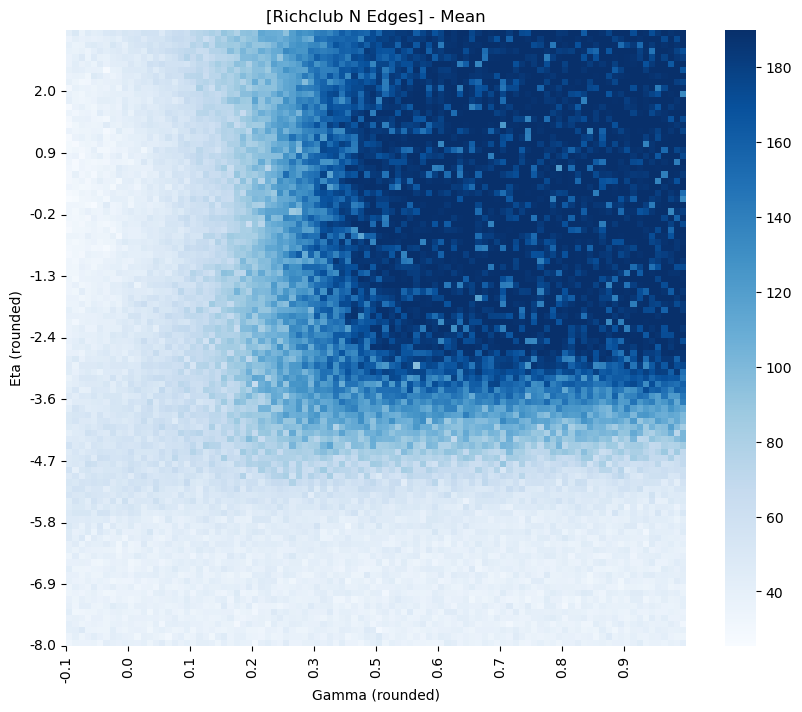

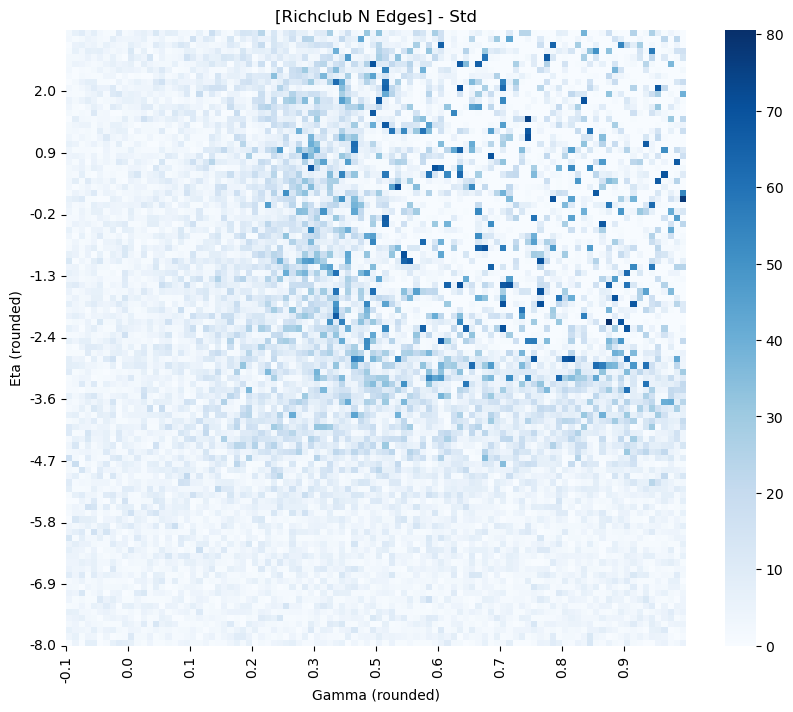

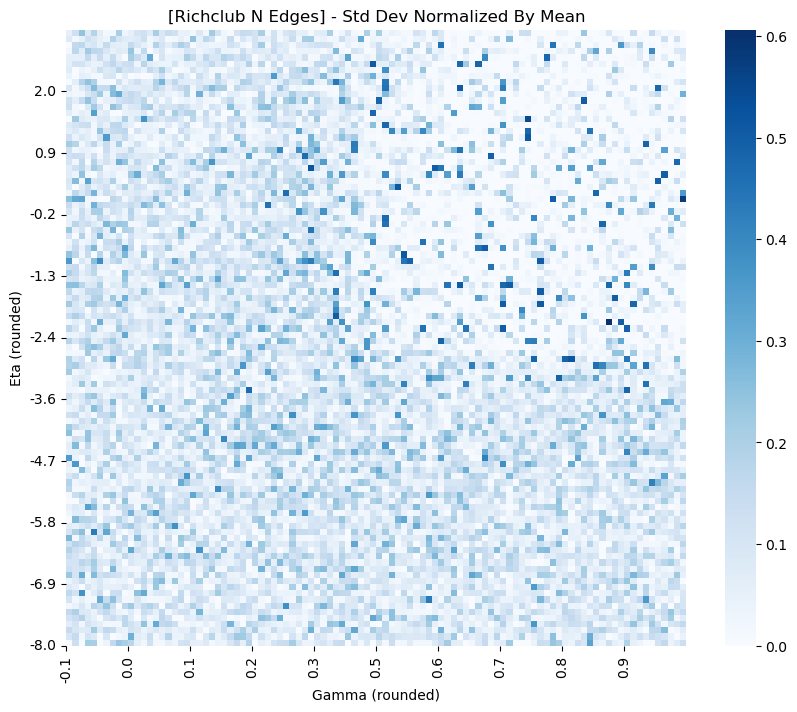

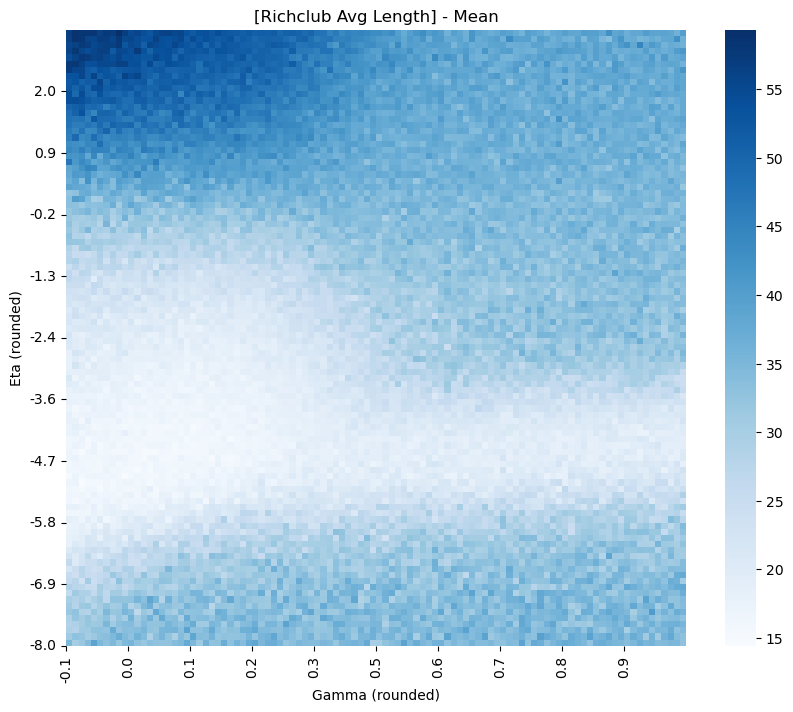

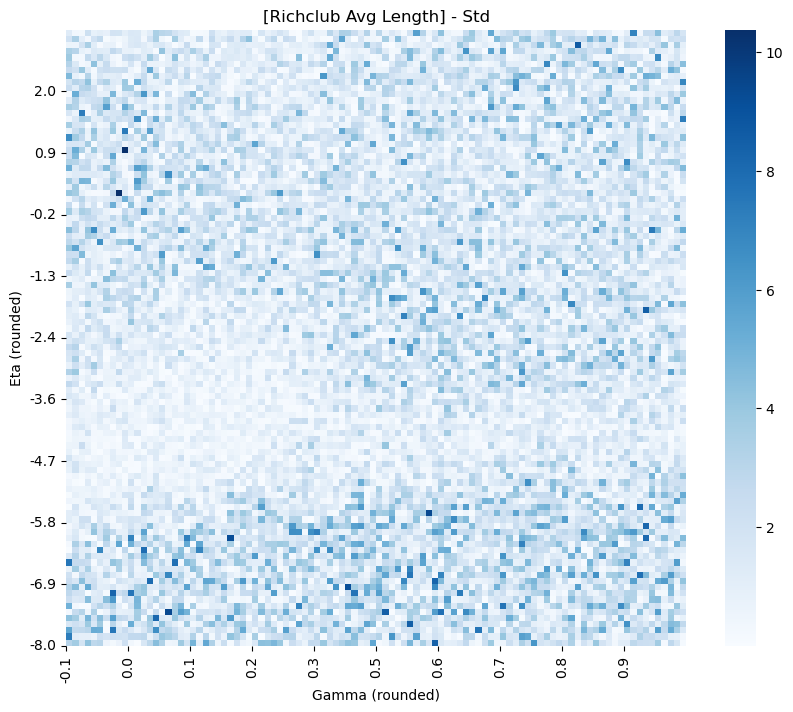

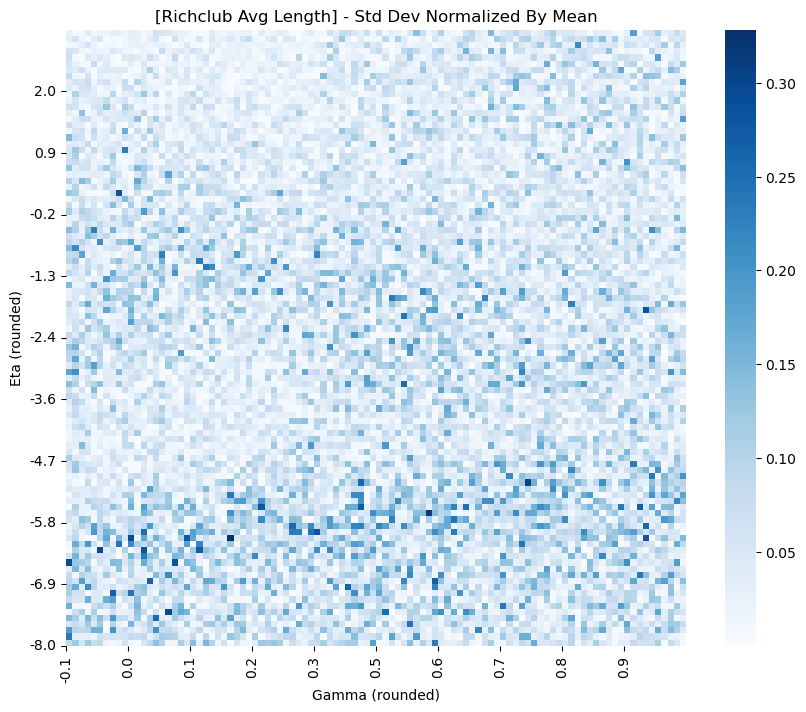

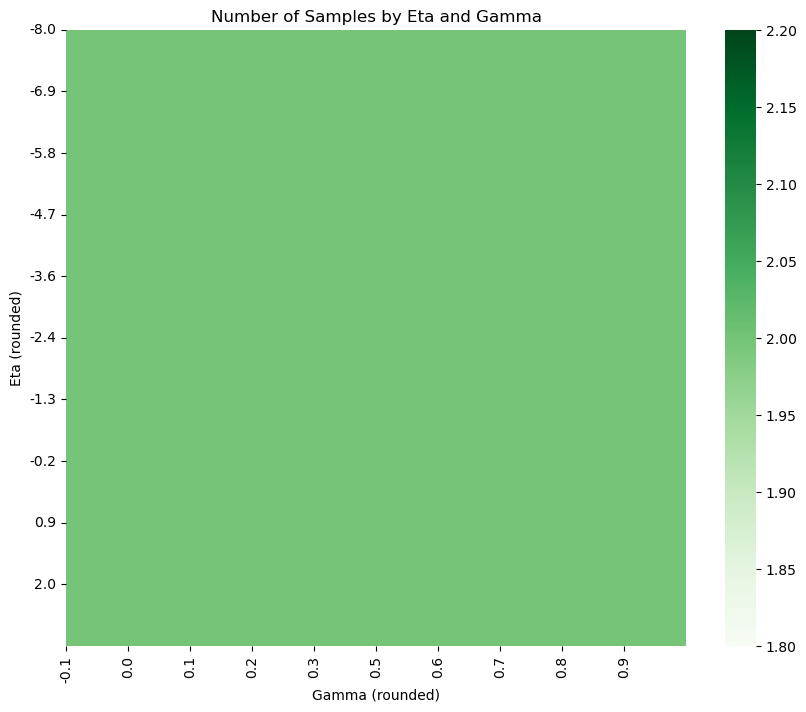

In [2]:
# Read the CSV file
path_to_csv_file = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/75_10000_samples_hopefully_no_lost_entries_gamma_-0p1_to_1_animal_206/all_metrics_for_75_10000_samples_hopefully_no_lost_entries_gamma_-0p1_to_1_animal_206_all.csv"
# /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/63_fine_grid_animal_0/all_metrics_for_63_fine_grid_animal_0.csv'
quality_check_regarding_means_and_avgs(path_to_csv_file, bin_into_100=False) 


Grouped Statistics by Eta and Gamma:
     eta gamma  \
                 
0      0     0   
1      0     1   
2      0     2   
3      0     3   
4      0     4   
...   ..   ...   
9995  99    95   
9996  99    96   
9997  99    97   
9998  99    98   
9999  99    99   

     MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)  \
                                                                 mean   
0                                                 0.835                 
1                                                 0.825                 
2                                                 0.850                 
3                                                 0.845                 
4                                                 0.790                 
...                                                 ...                 
9995                                              0.950                 
9996                                              0.940                

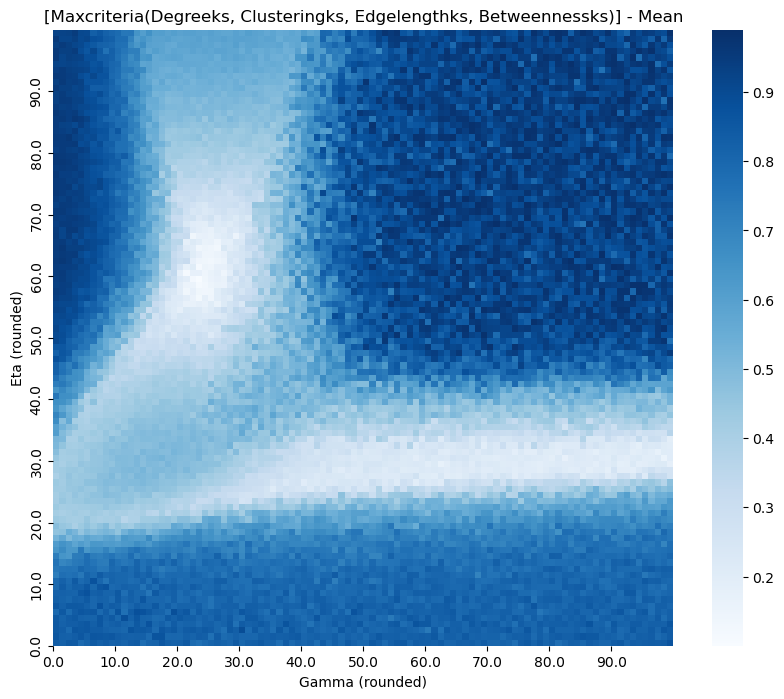

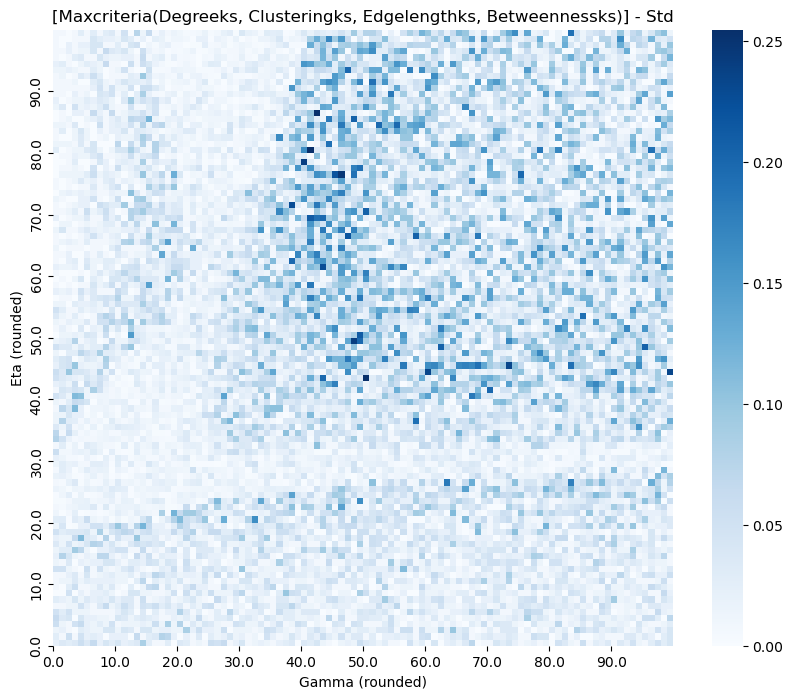

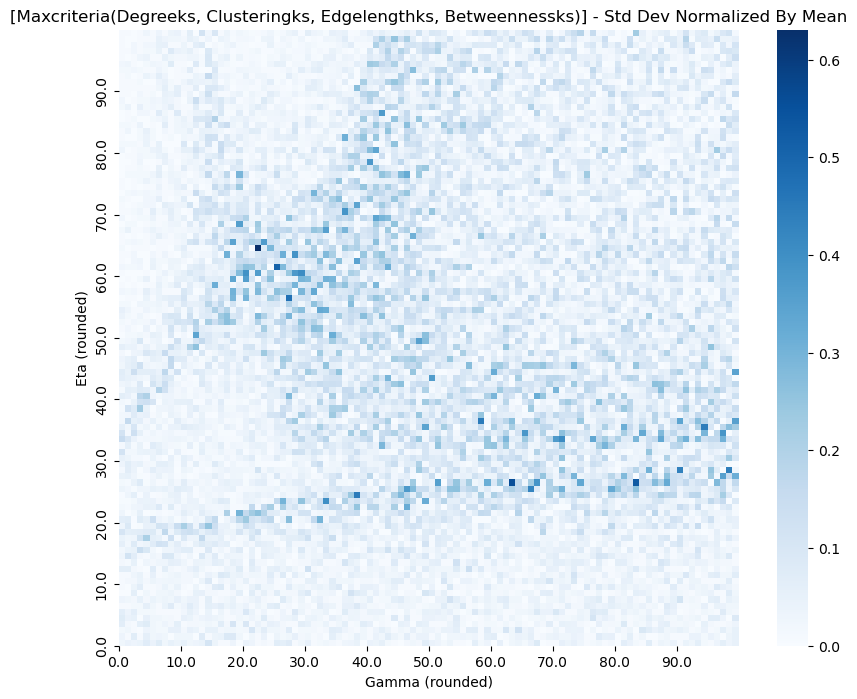

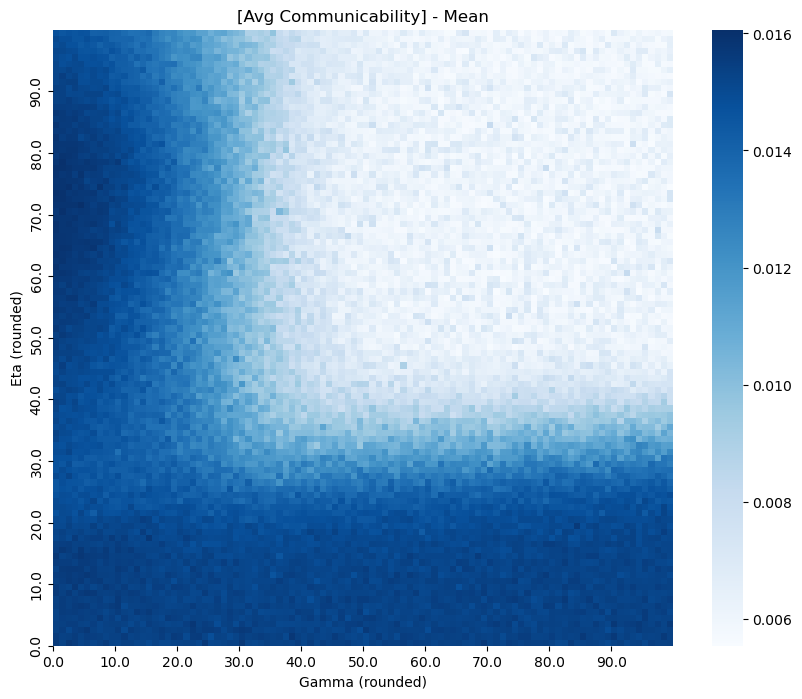

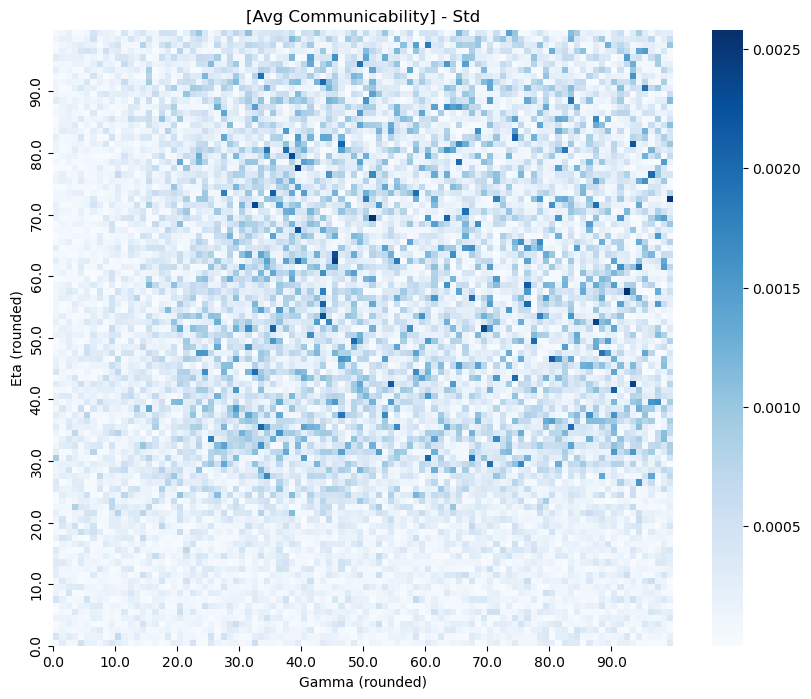

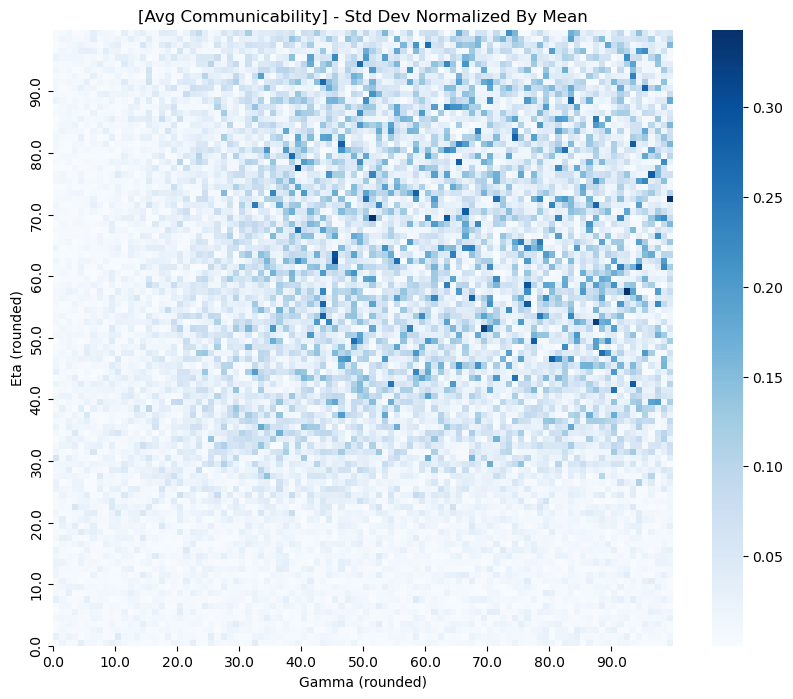

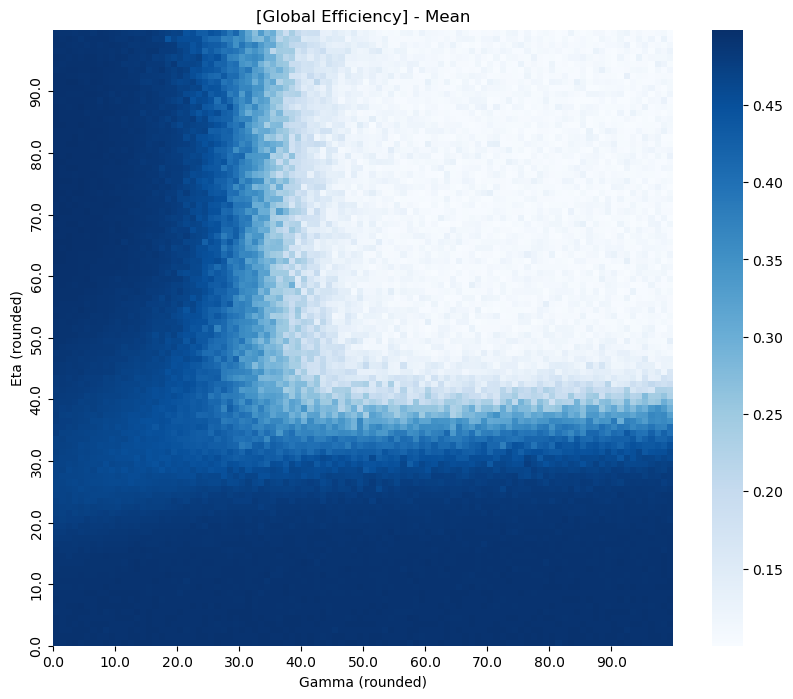

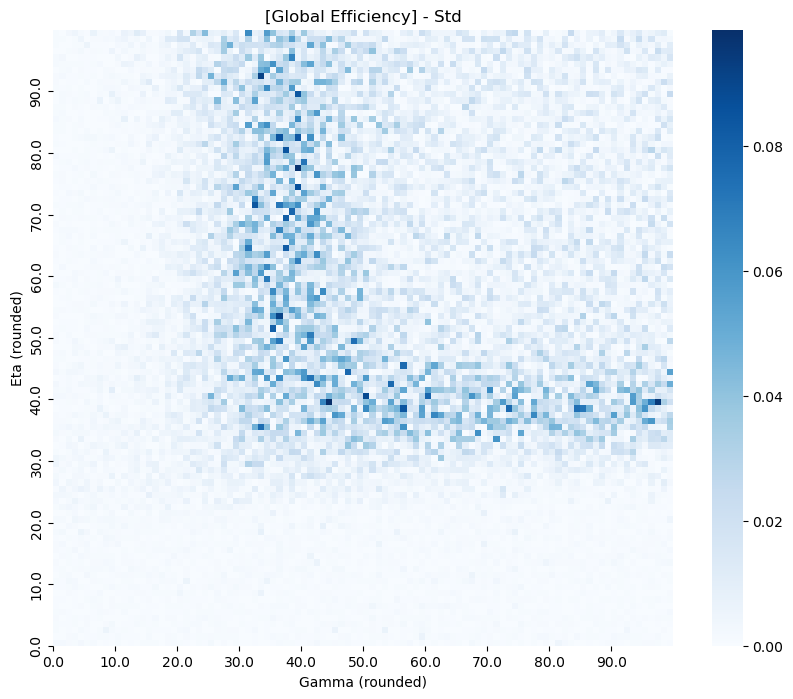

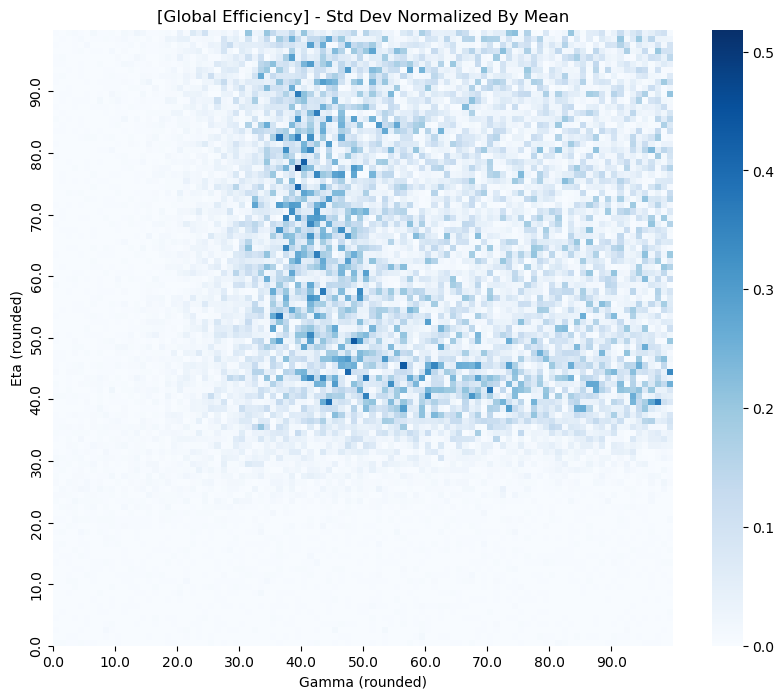

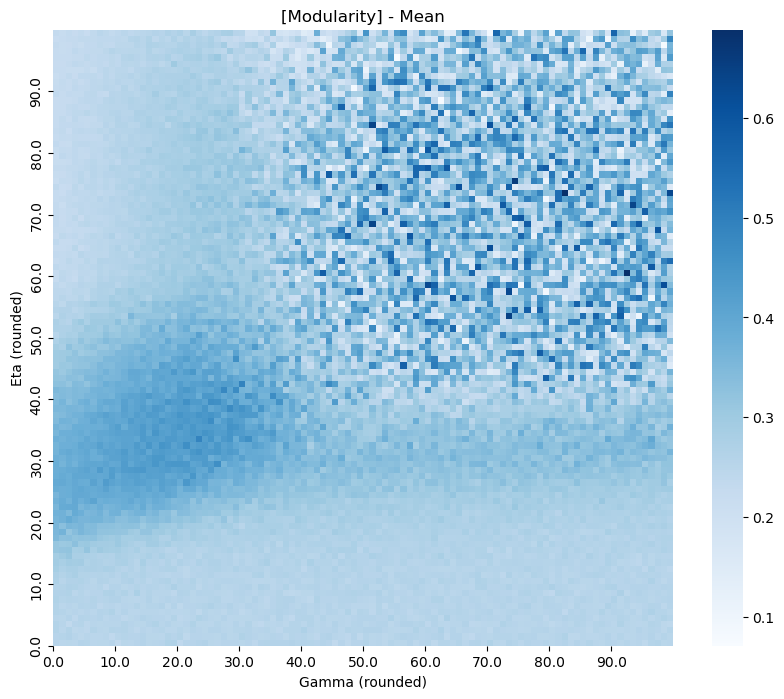

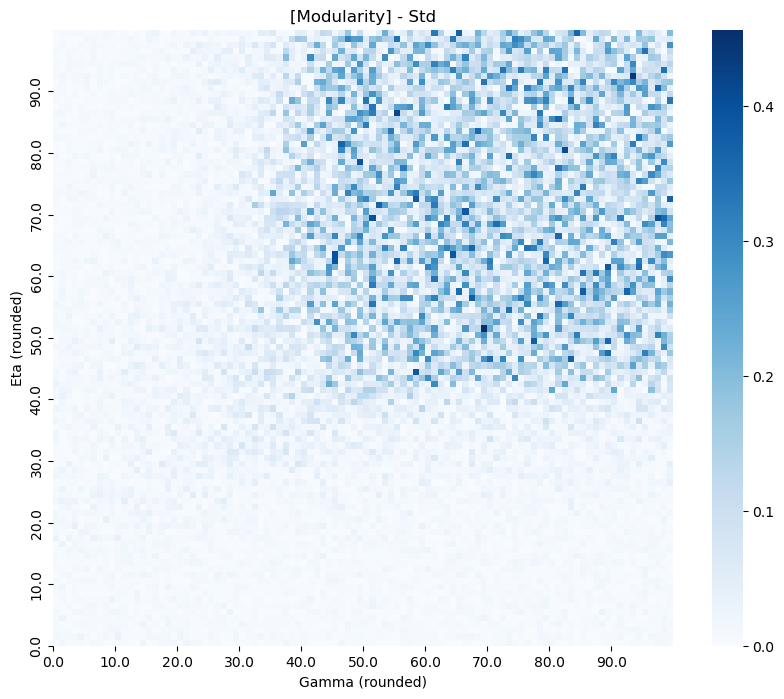

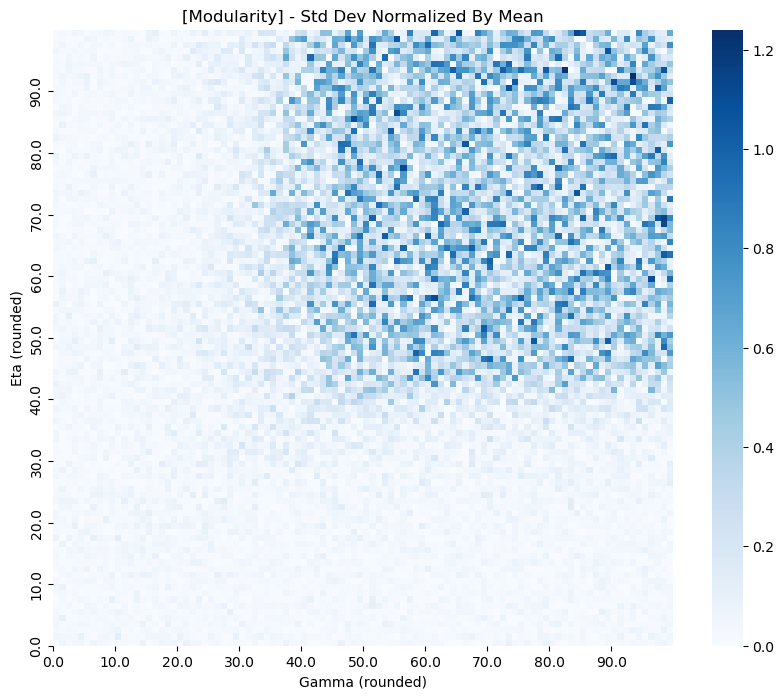

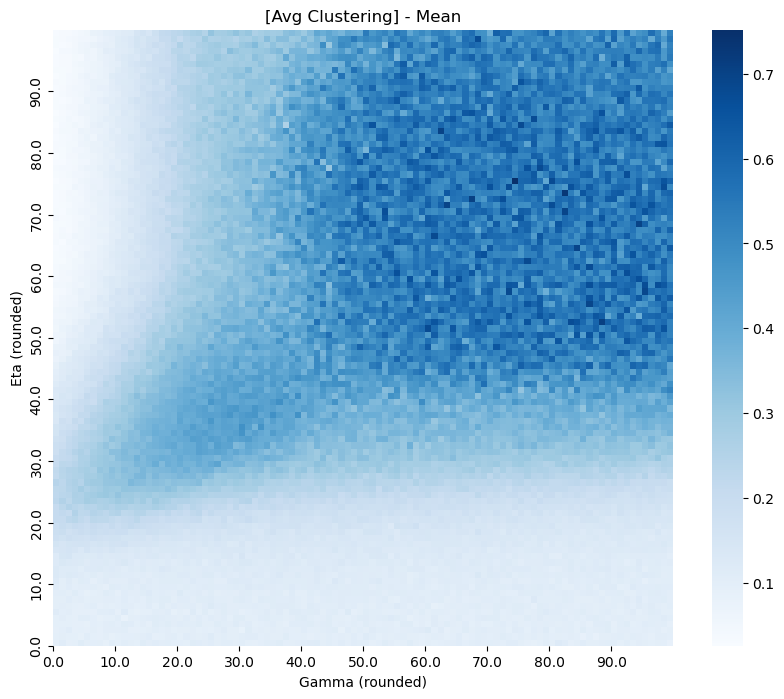

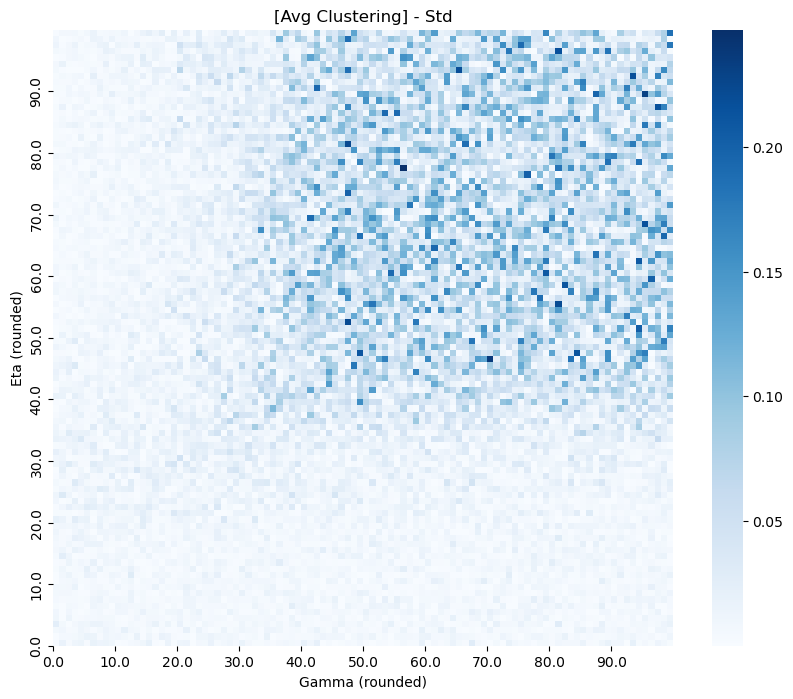

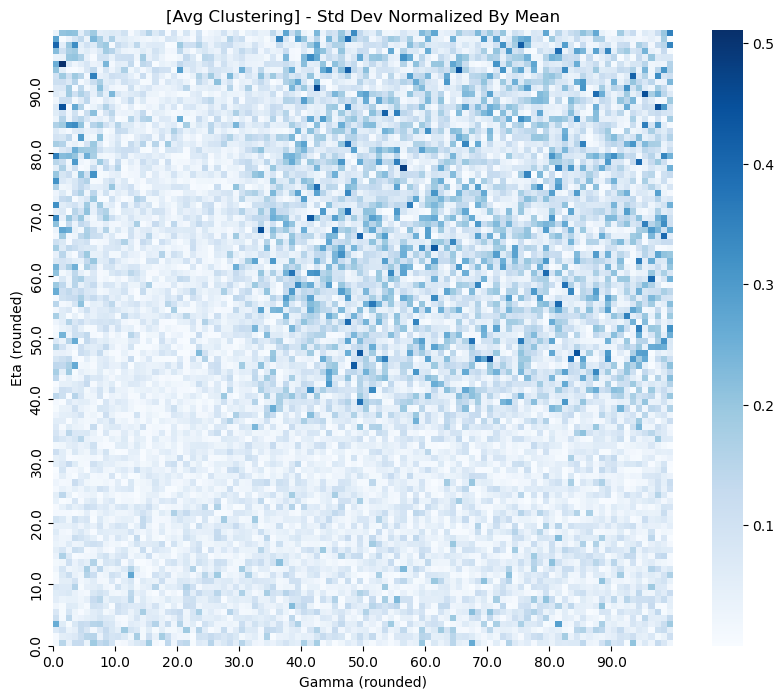

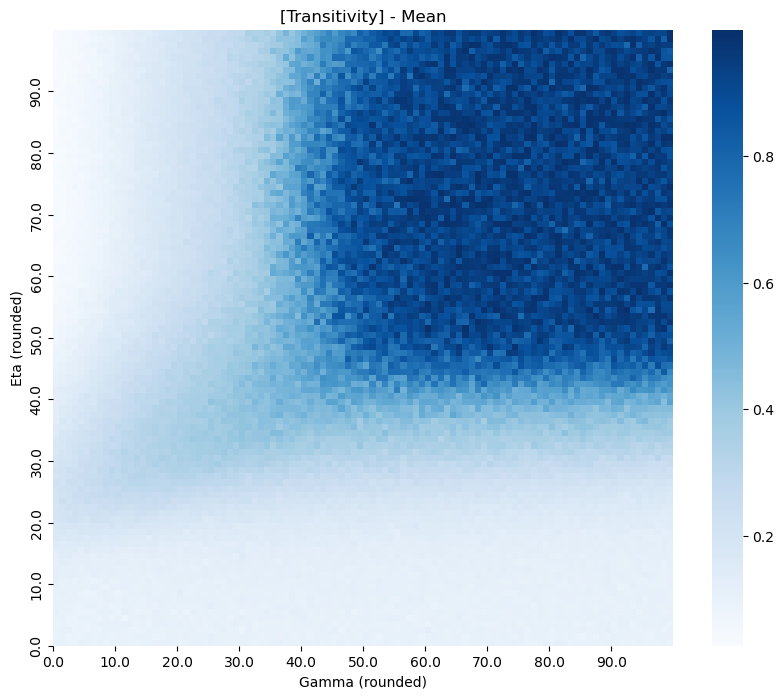

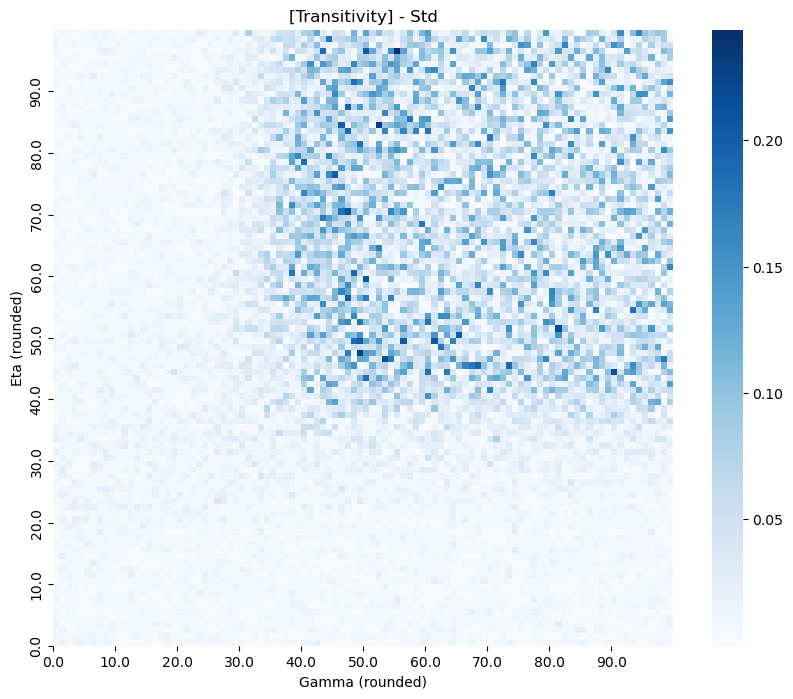

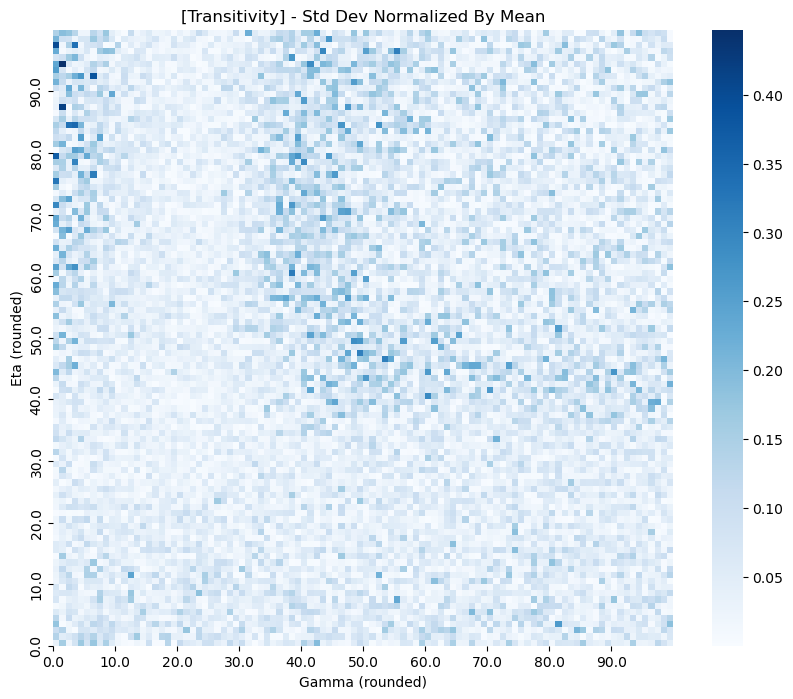

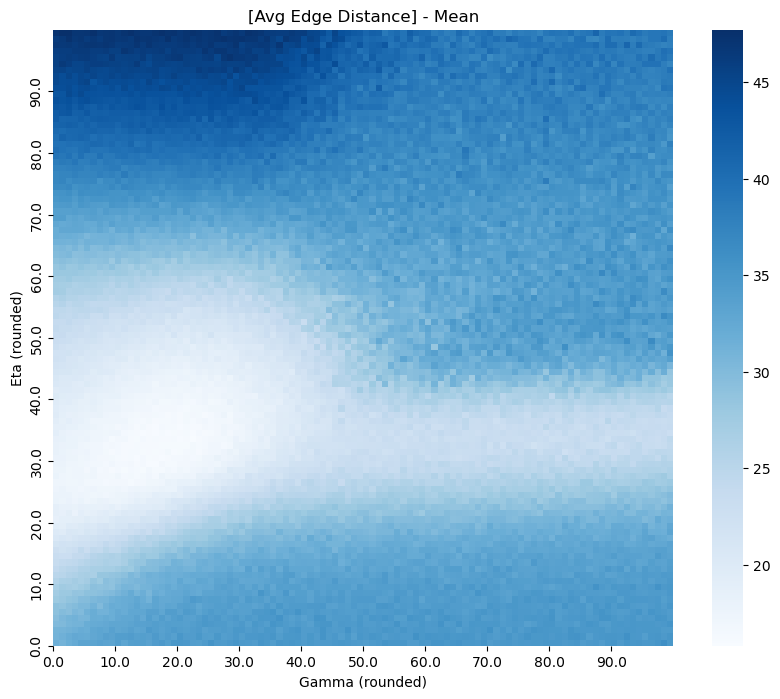

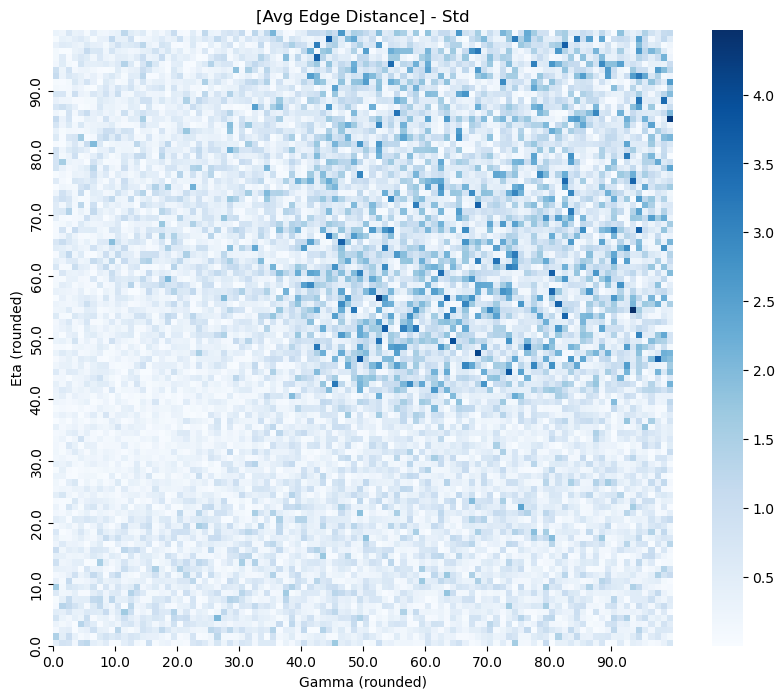

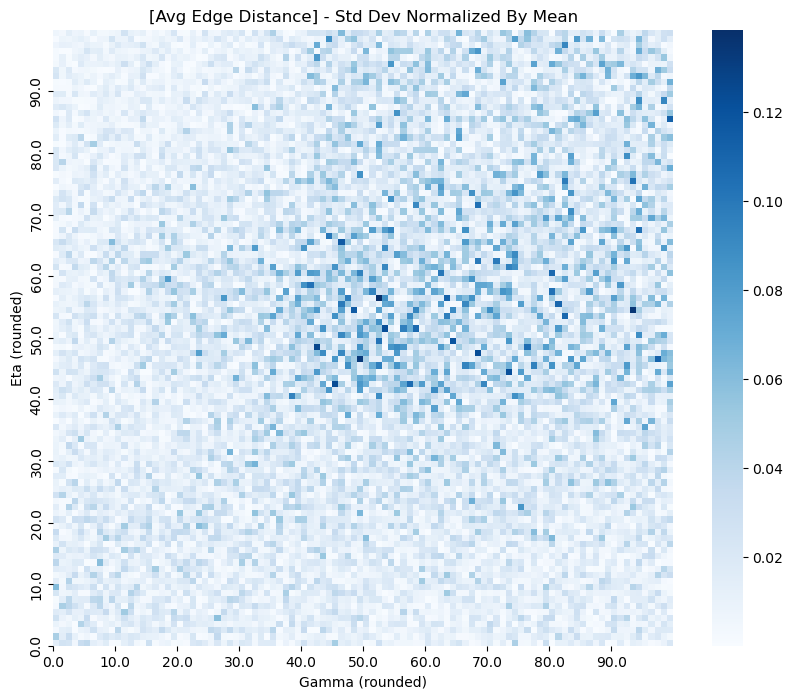

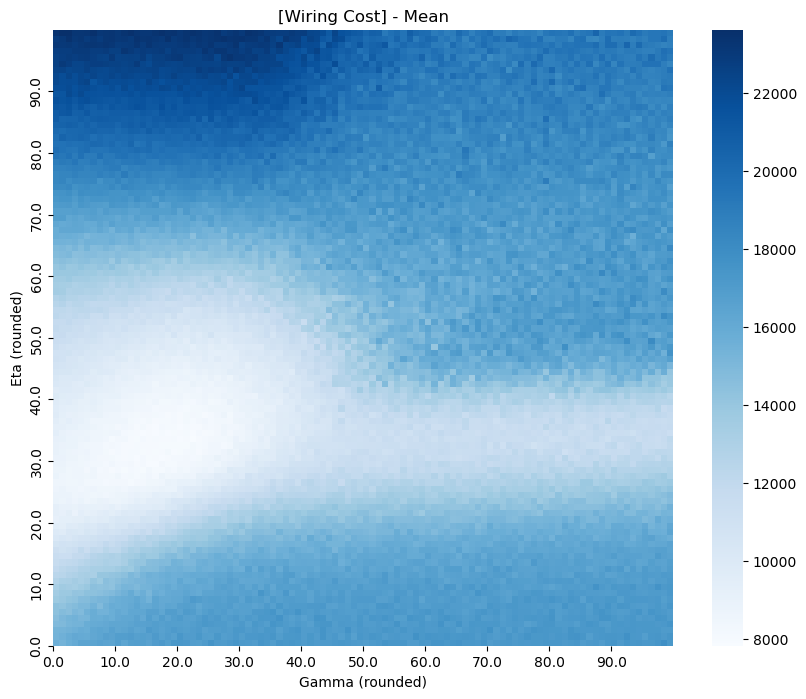

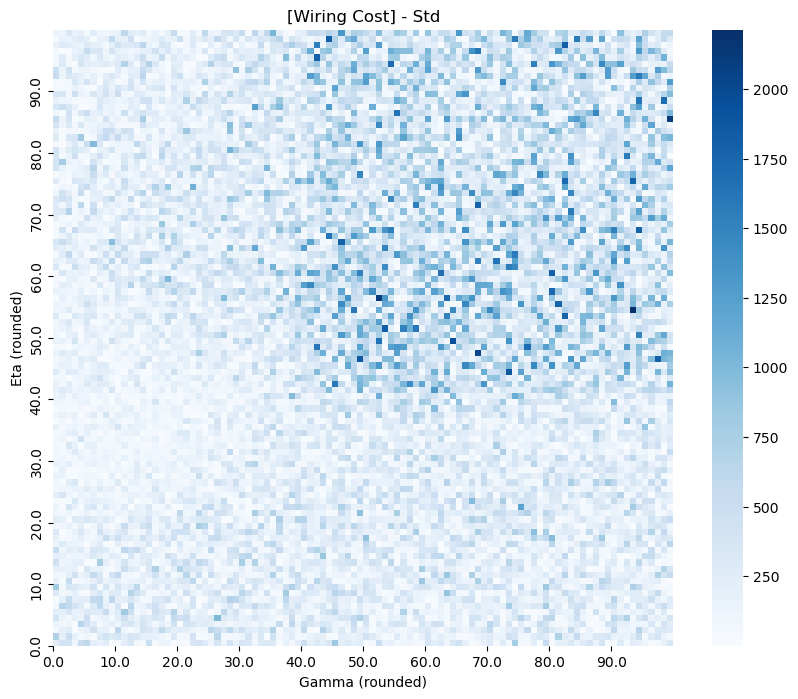

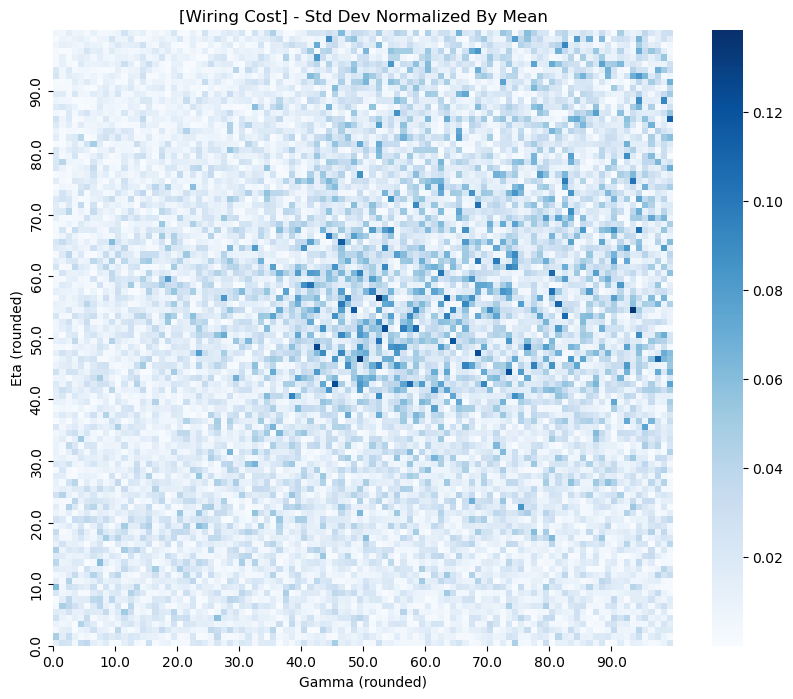

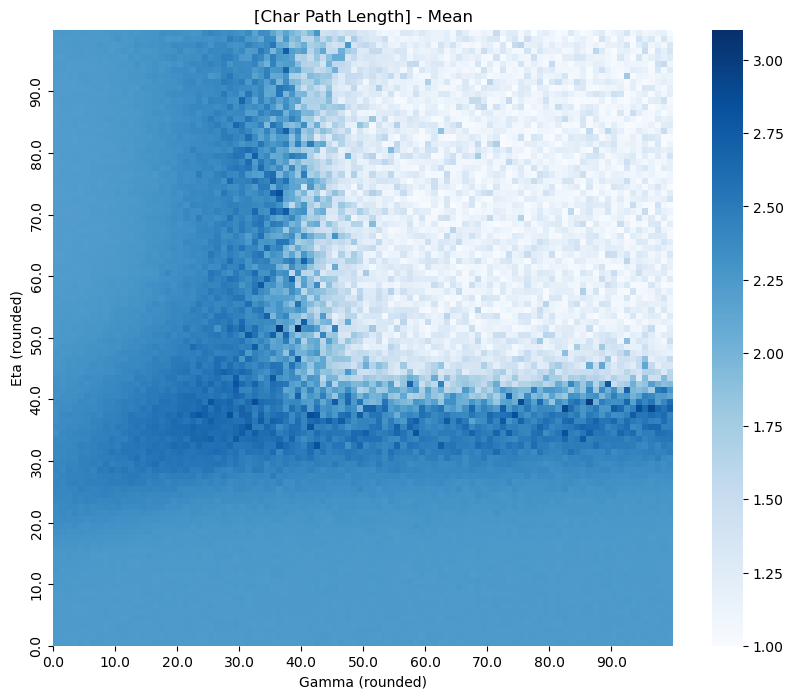

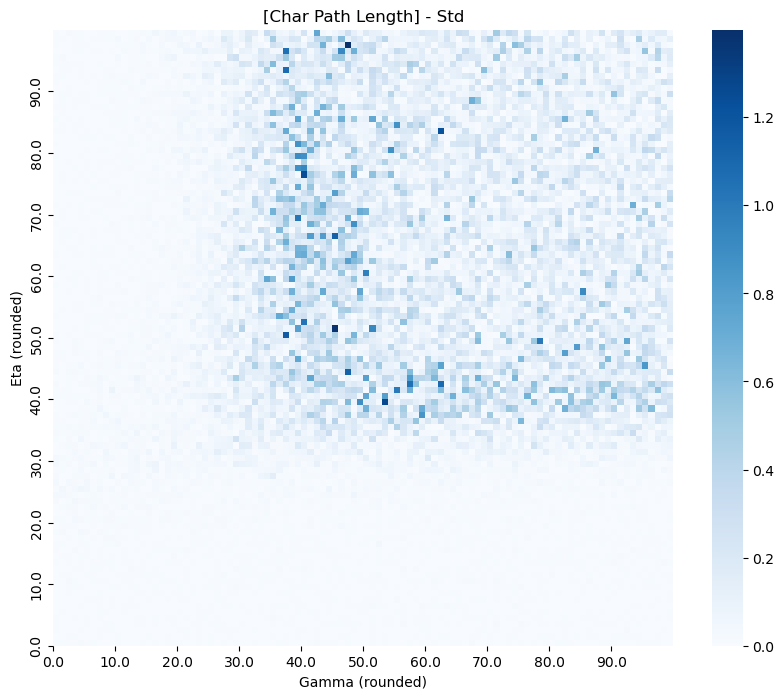

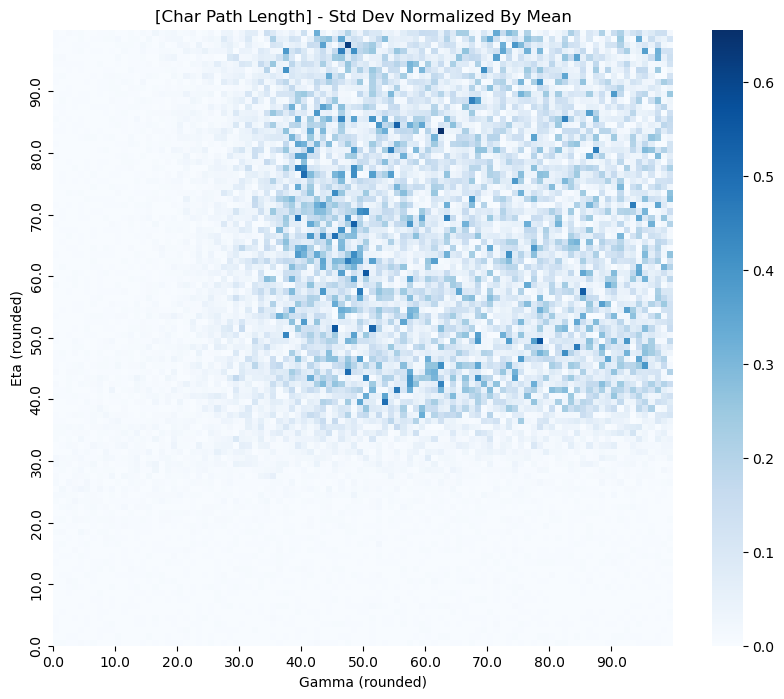

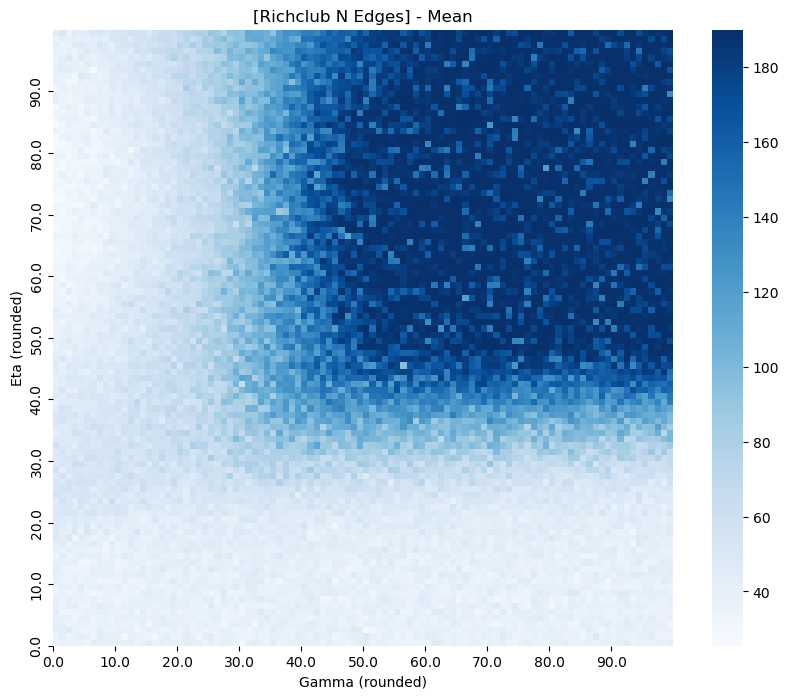

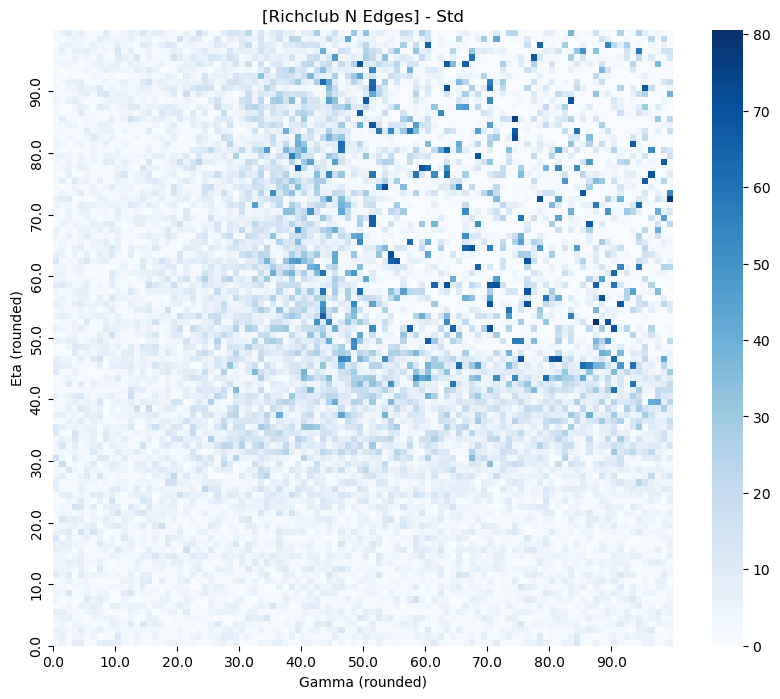

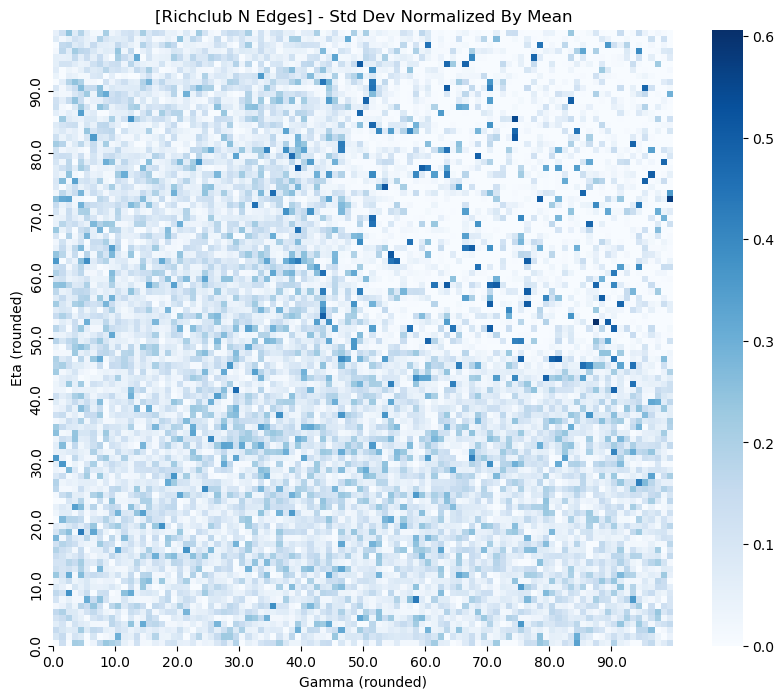

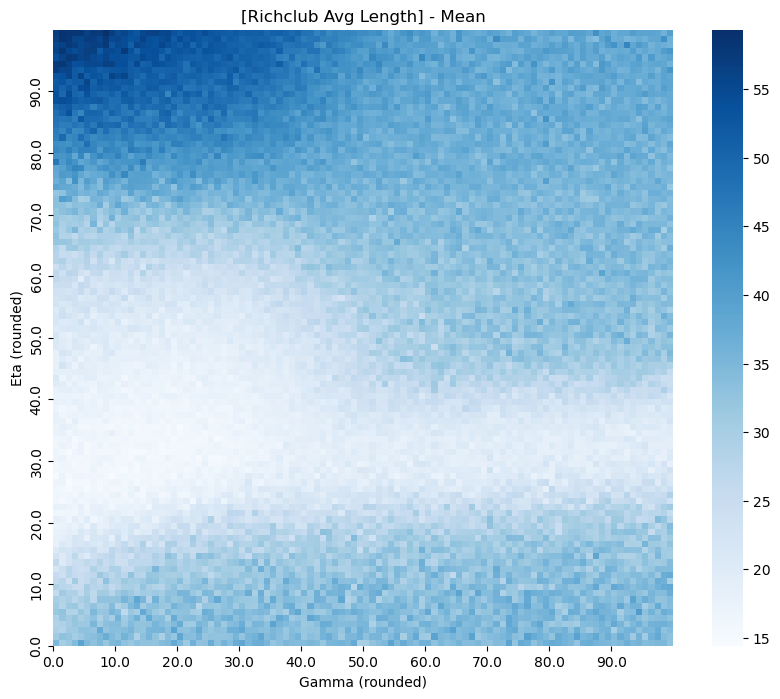

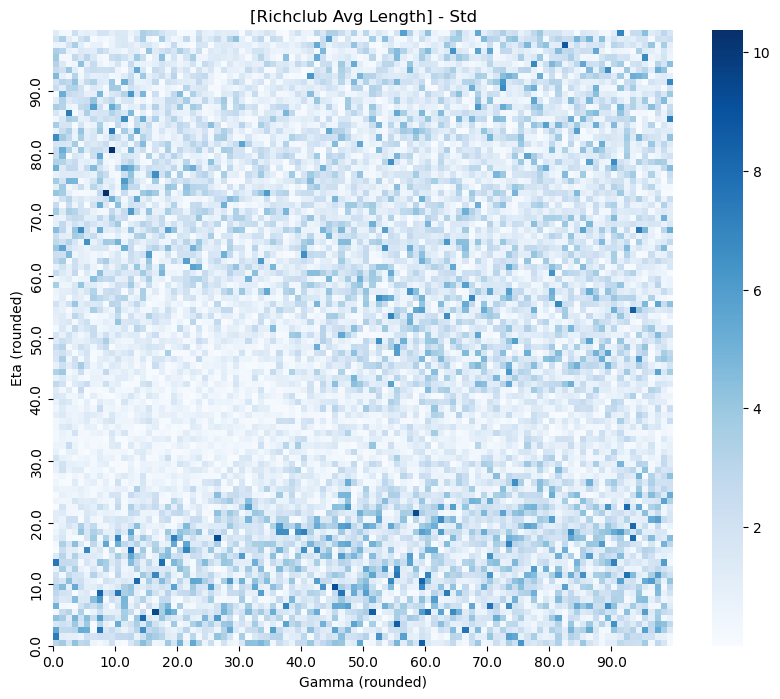

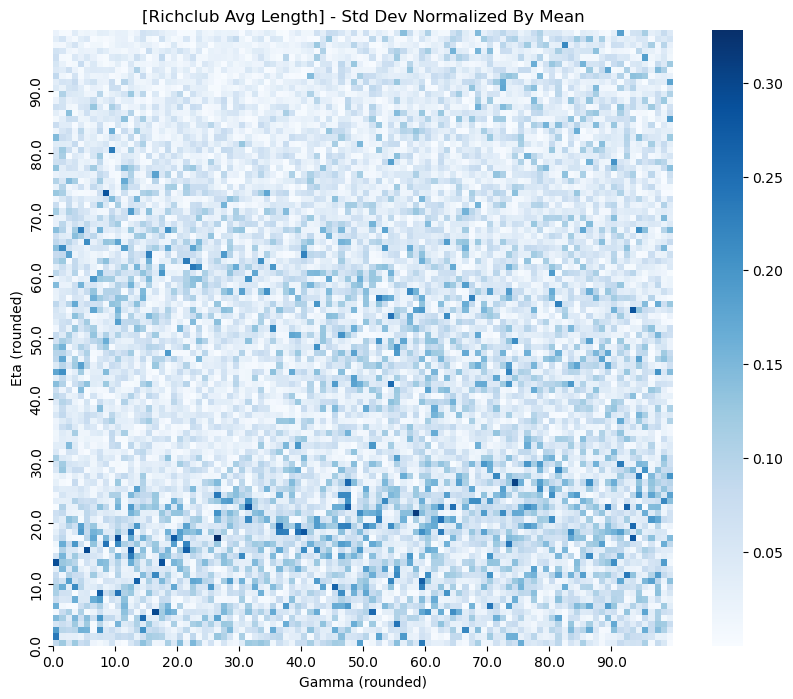

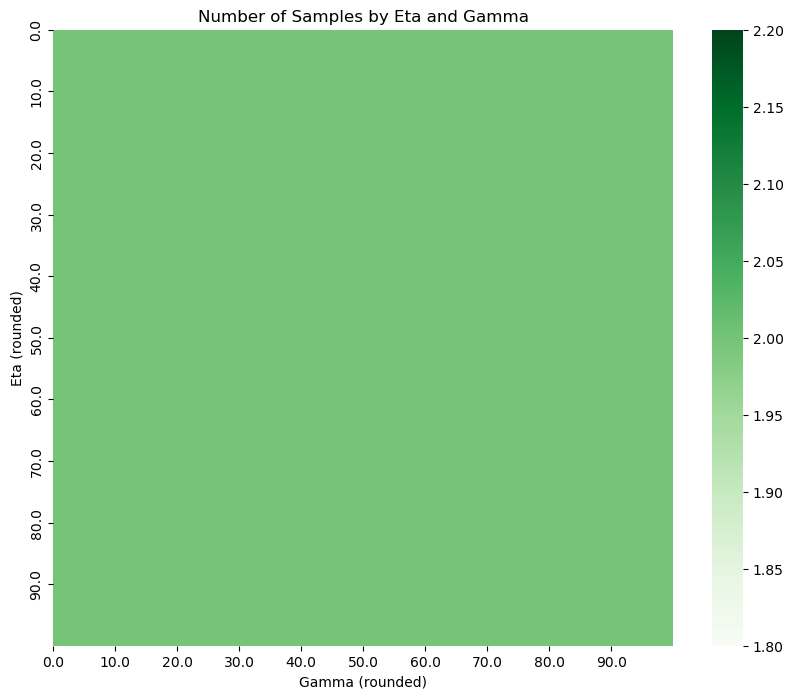

In [3]:

path_to_csv_file = Path(path_to_csv_file)
df = pd.read_csv(path_to_csv_file)

# Define the columns to analyze (excluding eta, gamma, and other metadata)
metric_columns = [
    'MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)',
    'avg_communicability',
    'global_efficiency',
    'modularity',
    'avg_clustering',
    'transitivity',
    'avg_edge_distance',
    'wiring_cost',
    'char_path_length',
    'richclub_n_edges',
    'richclub_avg_length'
]

# Group by eta and gamma, then calculate mean and std for each metric. Group into 100 bins for eta and gamma first!

df['eta'] = pd.cut(df['eta'], bins=100, labels=False)
df['gamma'] = pd.cut(df['gamma'], bins=100, labels=False)
# Group by eta and gamma, then calculate mean and std for each metric
grouped = df.groupby(['eta', 'gamma'])[metric_columns].agg(['mean', 'std']).reset_index()

# Display the grouped statistics
print("Grouped Statistics by Eta and Gamma:")
print(grouped)
print(f"\nNumber of unique eta-gamma combinations: {len(grouped)}")

# Prepare data for heatmaps
output_folder = path_to_csv_file.parent / 'heatmaps_mean_and_std/'
os.makedirs(output_folder, exist_ok=True)

# plot it
things = ["mean", "std", "std_dev_normalized_by_mean"]
for metric in metric_columns:
    for thing in things:
        plt.figure(figsize=(10, 8))
        pivot_table = grouped.pivot(index='eta', columns='gamma', values=(metric, thing if thing != "std_dev_normalized_by_mean" else 'std'))
        if thing == "std_dev_normalized_by_mean":
            pivot_table = pivot_table / grouped.pivot(index='eta', columns='gamma', values=(metric, 'mean'))
        sns.heatmap(pivot_table, # annot=True, 
                    fmt=".2f", cmap="Blues") # YlGnBu")
        
        # Invert y-axis
        plt.gca().invert_yaxis()

        plt.title(f'[{metric.replace("_", " ").title()}] - {thing.replace("_", " ").title()}') #  by Eta and Gamma')
        plt.xlabel('Gamma (rounded)')
        plt.ylabel('Eta (rounded)')
        
        # Change ticks to not have the bin numbers but the actual ranges
        plt.xticks(ticks=np.arange(len(pivot_table.columns)), labels=[f"{x:.1f}" for x in pivot_table.columns])
        plt.yticks(ticks=np.arange(len(pivot_table.index)), labels=[f"{y:.1f}" for y in pivot_table.index])
        
        # Make ticks readable
        distance = 10
        plt.xticks(ticks=np.arange(len(pivot_table.columns)//distance)*distance, labels=[f"{x:.1f}" for x in pivot_table.columns[::distance]])  # Show not every label
        plt.yticks(ticks=np.arange(len(pivot_table.index)//distance)*distance, labels=[f"{y:.1f}" for y in pivot_table.index[::distance]])  # Show not every label

        plt.savefig(output_folder / f'{metric}_{thing}.pdf')
        plt.show()
    
    
# Similar to the style above: Plot how many samples went into each point in the heatmap
plt.figure(figsize=(10, 8))
count_pivot_table = df.groupby(['eta', 'gamma']).size().unstack(fill_value=0)
sns.heatmap(count_pivot_table, # annot=True, 
            fmt="d", cmap="Greens")
plt.title('Number of Samples by Eta and Gamma')
plt.xlabel('Gamma (rounded)')
plt.ylabel('Eta (rounded)')     
# Make ticks readable
distance = 10
plt.xticks(ticks=np.arange(len(count_pivot_table.columns)//distance)*distance, labels=[f"{x:.1f}" for x in count_pivot_table.columns[::distance]])  # Show not every label
plt.yticks(ticks=np.arange(len(count_pivot_table.index)//distance)*distance, labels=[f"{y:.1f}" for y in count_pivot_table.index[::distance]])  # Show not every label
plt.savefig(output_folder / f'count_samples.pdf')
plt.show()
